# TP de Regresión — Predicción de precios de casas
### Aprendizaje Automático 1 — Tecnicatura en Inteligencia Artificial (FCEIA - UNR)

**Integrantes:** Aguirre, Gambande, Paladini



# Consigna 3:

---
## 3.1 Configuración del entorno y carga de datos

In [247]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Configuración global de visualización (consistencia entre gráficos)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42  # semilla fija para reproducibilidad

In [248]:
# Carga del dataset
df = pd.read_csv('data/house-prices-tp.csv') 

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 556 filas x 14 columnas


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.07151,0.0,4.49,0.0,0.449,6.121,56.8,3.7476,3.0,247.0,18.5,395.15,8.44,22.2
1,0.08265,0.0,13.92,0.0,0.437,6.127,18.4,5.5027,4.0,289.0,16.0,396.90,8.58,23.9
2,0.12816,12.5,6.07,0.0,0.409,5.885,33.0,6.4980,4.0,345.0,18.9,396.90,8.79,20.9
3,0.08873,21.0,5.64,0.0,0.439,5.963,45.7,6.8147,4.0,243.0,16.8,395.56,13.45,19.7
4,0.11432,0.0,8.56,0.0,0.520,6.781,71.3,2.8561,5.0,384.0,20.9,395.58,7.67,26.5


---
## 3.2 Inspección del dataset

In [249]:
# Tipos de datos y nulos por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     533 non-null    float64
 1   ZN       534 non-null    float64
 2   INDUS    541 non-null    float64
 3   CHAS     533 non-null    float64
 4   NOX      532 non-null    float64
 5   RM       535 non-null    float64
 6   AGE      532 non-null    float64
 7   DIS      541 non-null    float64
 8   RAD      528 non-null    float64
 9   TAX      538 non-null    float64
 10  PTRATIO  528 non-null    float64
 11  B        534 non-null    float64
 12  LSTAT    534 non-null    float64
 13  MEDV     535 non-null    float64
dtypes: float64(14)
memory usage: 60.9 KB


In [250]:
# Separación de variables por tipo
# CHAS es una dummy, hay que tratarla como categórica

cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_numericas.remove('MEDV')  # varaible target se analiza aparte
col_categorica = 'CHAS'
if col_categorica in cols_numericas:
    cols_numericas.remove(col_categorica)

print(f'Variables numéricas continuas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variable categórica (dummy): {col_categorica}')
print('Variable target: MEDV')

Variables numéricas continuas (12): ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Variable categórica (dummy): CHAS
Variable target: MEDV


---
## 3.3 Análisis descriptivo

Medidas de tendencia central, dispersión, sesgo y curtosis para cada variable numérica.

- Esto permite entender rango de variación y forma de la distribución de cada variable antes de decidir
transformaciones o tratamiento de outliers.

In [251]:
desc = df[cols_numericas + ['MEDV']].describe().T
# el .T transpone la tabla para ver una fila por variable con sus datos estadisticos

desc['mediana'] = df[cols_numericas + ['MEDV']].median()

desc['sesgo'] = df[cols_numericas + ['MEDV']].skew()
# Mide qué tan asimétrica es la distribución de cada variable: 
# 0 = simétrica, positivo = cola hacia la derecha, negativo = cola hacia la izquierda

desc['curtosis'] = df[cols_numericas + ['MEDV']].kurtosis()
# Mide qué tan pesadas son las colas de la distribución comparado con una normal
# valores altos indican más outliers/valores extremos: leptocurtica (colas pesadas, pico mas pronunciado).
# valores bajos indican una distribución más achatada: platicurtica (colas livianas, distribucion mas aplanada).

desc[['mean', 'mediana', 'std', 'min', '25%', '50%', '75%', 'max', 'sesgo', 'curtosis']]

,mean,mediana,std,min,25%,50%,75%,max,sesgo,curtosis
CRIM,5.845517,0.315330,13.828631,0.00632,0.08447,0.315330,4.871410,88.9762,3.746677,15.248736
ZN,13.197175,0.000000,24.902981,0.00000,0.00000,0.000000,20.000000,100.0000,1.957797,2.749832
INDUS,11.218725,9.690000,6.942021,0.46000,5.13000,9.690000,18.100000,27.7400,0.301523,-1.206425
NOX,0.560050,0.538000,0.119472,0.38500,0.45300,0.538000,0.643986,0.8710,0.694358,-0.229572
RM,6.291839,6.208000,0.782403,3.56100,5.87550,6.208000,6.638500,8.7800,0.373812,1.555062
AGE,67.632303,76.500000,28.461925,2.90000,42.27500,76.500000,93.825000,100.0000,-0.550692,-1.038192
DIS,3.944102,3.340107,2.255689,1.12960,2.11210,3.340107,5.400700,12.1265,1.078906,0.705364
RAD,9.699379,5.000000,8.684495,1.00000,4.00000,5.000000,23.632660,24.0000,0.951478,-0.947840
TAX,409.575089,335.000000,167.689379,187.00000,279.00000,335.000000,666.000000,711.0000,0.632306,-1.170504
PTRATIO,18.429904,19.000000,2.194759,12.60000,17.00000,19.000000,20.200000,22.0000,-0.787238,-0.304842


Las variables CRIM, B, ZN, DIS y MEDV presentan sesgo marcado (|sesgo| > 1). CRIM y B son las más extremas: 
- **CRIM** tiene cola derecha muy larga y además tiene una curtosis muy elevada (15.25) (leptocurtica), lo que indica una distribución con colas muy pesada 
- mientras que **B** presenta un sesgo negativo fuerte y curtosis alta (4.50) (leptocurtica).
- Estas variables son candidatas a una **transformación logarítmica** antes de entrenar el modelo de regresión, ya que la regresión lineal asume relaciones lineales y errores homocedásticos, y una distribución muy sesgada puede violar esos supuestos.
- MEDV al ser el target también sugiere evaluar una transformación logarítmica, aunque eso complica la interpretación

(array([374.,  40.,  26.,  22.,  16.,   7.,   7.,   4.,   6.,   2.,   4.,
          1.,   2.,   1.,   2.,   3.,   1.,   1.,   1.,   1.,   0.,   1.,
          2.,   0.,   2.,   2.,   3.,   0.,   0.,   2.]),
 array([6.32000000e-03, 2.97198267e+00, 5.93764533e+00, 8.90330800e+00,
        1.18689707e+01, 1.48346333e+01, 1.78002960e+01, 2.07659587e+01,
        2.37316213e+01, 2.66972840e+01, 2.96629467e+01, 3.26286093e+01,
        3.55942720e+01, 3.85599347e+01, 4.15255973e+01, 4.44912600e+01,
        4.74569227e+01, 5.04225853e+01, 5.33882480e+01, 5.63539107e+01,
        5.93195733e+01, 6.22852360e+01, 6.52508987e+01, 6.82165613e+01,
        7.11822240e+01, 7.41478867e+01, 7.71135493e+01, 8.00792120e+01,
        8.30448747e+01, 8.60105373e+01, 8.89762000e+01]),
 <BarContainer object of 30 artists>)

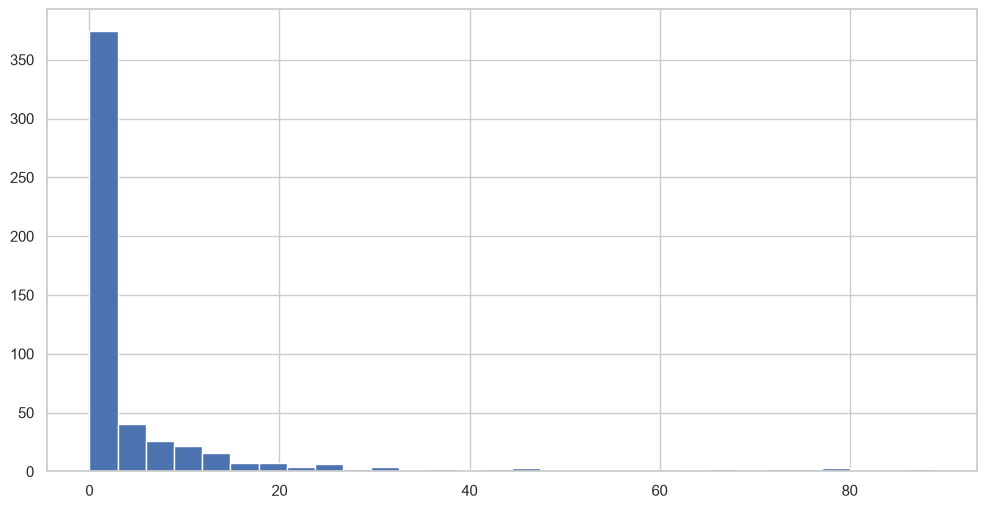

In [252]:
plt.hist(df["CRIM"], bins=30)

(array([ 10.,   6.,   4.,   4.,   2.,   3.,   6.,   6.,   2.,   3.,   1.,
          1.,   2.,   2.,   2.,   3.,   1.,   2.,   5.,   4.,   1.,   3.,
          6.,   6.,   7.,   9.,  18.,  17.,  61., 337.]),
 array([3.20000000e-01, 1.35393333e+01, 2.67586667e+01, 3.99780000e+01,
        5.31973333e+01, 6.64166667e+01, 7.96360000e+01, 9.28553333e+01,
        1.06074667e+02, 1.19294000e+02, 1.32513333e+02, 1.45732667e+02,
        1.58952000e+02, 1.72171333e+02, 1.85390667e+02, 1.98610000e+02,
        2.11829333e+02, 2.25048667e+02, 2.38268000e+02, 2.51487333e+02,
        2.64706667e+02, 2.77926000e+02, 2.91145333e+02, 3.04364667e+02,
        3.17584000e+02, 3.30803333e+02, 3.44022667e+02, 3.57242000e+02,
        3.70461333e+02, 3.83680667e+02, 3.96900000e+02]),
 <BarContainer object of 30 artists>)

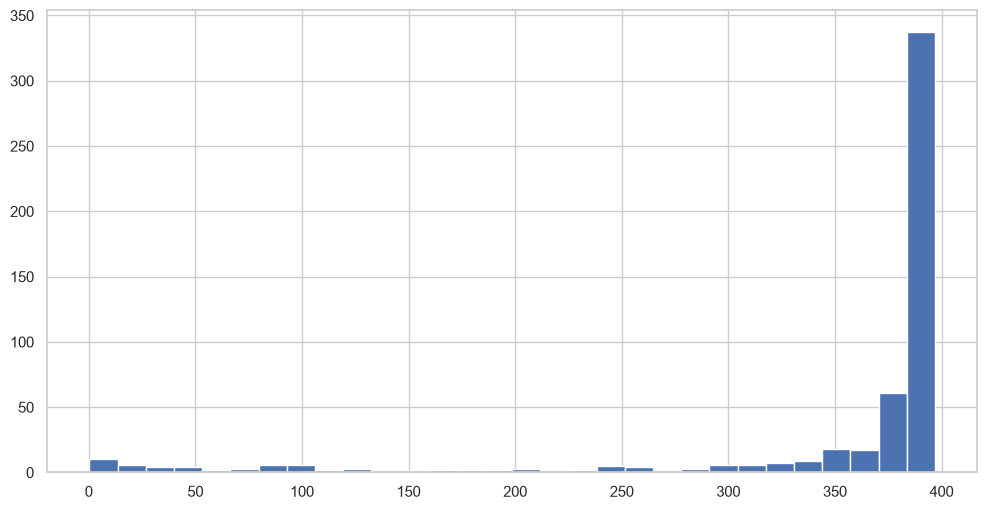

In [253]:
plt.hist(df["B"], bins=30)

- **RAD**:los percentiles de la tabla muestran un salto brusco entre la mediana (5.0) y el percentil 75 (23.63), lo cual no es compatible con una distribución gradual.

In [254]:
# Verificación del patrón bimodal de RAD a partir de los percentiles
df['RAD'].value_counts().sort_index()

RAD
1.000000      20
1.307128       1
2.000000      24
2.402424       1
2.573615       1
3.000000      38
3.056548       1
4.000000     110
4.528569       1
4.811748       1
5.000000     115
6.000000      26
6.850123       1
7.000000      17
8.000000      24
10.168701      1
10.554892      1
14.195528      1
14.638330      1
15.239579      1
17.000150      1
17.110181      1
17.164570      1
18.177503      1
19.266891      1
20.416908      1
21.900776      1
22.069511      1
22.328313      1
23.510213      1
24.000000    132
Name: count, dtype: int64

- Se confirma que RAD es bimodal: la mayoría de las observaciones se concentra en valores bajos (1 a 8), y un segundo grupo grande se concentra directamente en el valor máximo (24), sin observaciones intermedias
- Esto se va a poder observar en un histograma

- Nota sobre el tipo de RAD: aunque está codificada como número, RAD es conceptualmente una variable **ordinal** (un índice de accesibilidad a autopistas radiales), no una magnitud continua. El orden importa (mayor valor = mayor accesibilidad), pero la distancia entre sus valores no tiene un significado uniforme. De todas formas se la mantiene dentro de las variables numéricas.

(array([ 21.,  26.,  39., 111., 116.,  26.,  18.,  24.,   0.,   1.,   1.,
          0.,   0.,   0.,   2.,   1.,   0.,   3.,   1.,   1.,   0.,   1.,
          2.,   1., 133.]),
 array([ 1.  ,  1.92,  2.84,  3.76,  4.68,  5.6 ,  6.52,  7.44,  8.36,
         9.28, 10.2 , 11.12, 12.04, 12.96, 13.88, 14.8 , 15.72, 16.64,
        17.56, 18.48, 19.4 , 20.32, 21.24, 22.16, 23.08, 24.  ]),
 <BarContainer object of 25 artists>)

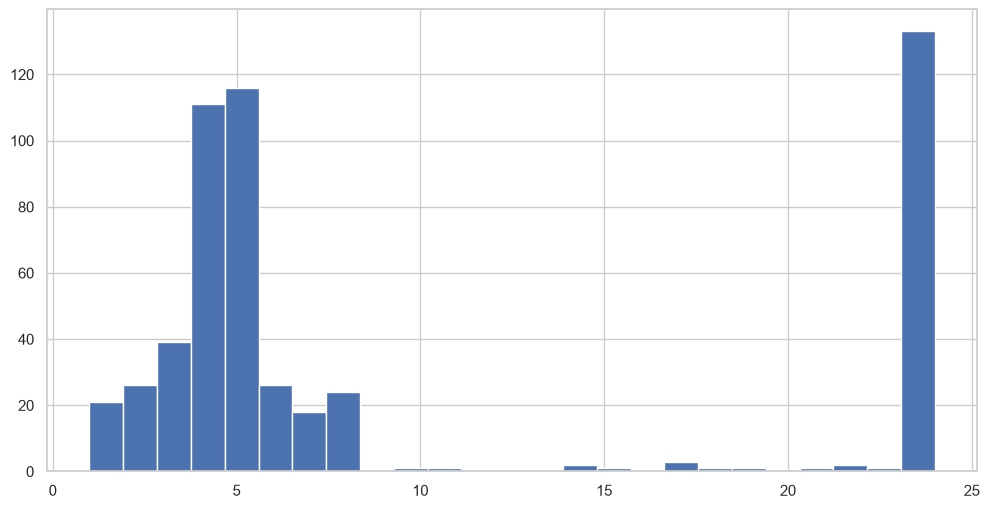

In [255]:
plt.hist(df["RAD"], bins=25)

In [256]:
# Distribución de la variable dummy CHAS
df[col_categorica].value_counts(dropna=False)

CHAS
0.0    485
1.0     48
NaN     23
Name: count, dtype: int64

---
## 3.4 Análisis y decisión sobre datos faltantes


In [257]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje_nulos.round(2)})
reporte_nulos = reporte_nulos[reporte_nulos['Nulos'] > 0].sort_values('Nulos', ascending=False)
reporte_nulos

,Nulos,Porcentaje (%)
PTRATIO,28,5.04
RAD,28,5.04
NOX,24,4.32
AGE,24,4.32
CHAS,23,4.14
CRIM,23,4.14
LSTAT,22,3.96
B,22,3.96
ZN,22,3.96
RM,21,3.78


- Cada columna tiene entre 2.70% y 5.04% de nulos.

### Análisis del mecanismo de los datos faltantes (MCAR / MAR / MNAR)

- MCAR -> la falta de dato es pura casualidad
- MAR -> la falta del dato depende de otras varaibles observadas, eliminar aca sesga, imputar con KNN
- MNAR -> la falta depende del propio valor faltante

In [258]:
# Chequeo: los nulos están relacionados con otra variable?
tiene_nulo = df.isnull().any(axis=1)

print('CRIM mediana en filas CON algún nulo:', df.loc[tiene_nulo, 'CRIM'].median())
print('CRIM mediana en filas SIN nulos:', df.loc[~tiene_nulo, 'CRIM'].median())

CRIM mediana en filas CON algún nulo: 45.877735005789845
CRIM mediana en filas SIN nulos: 0.25651


La falta de datos no parece ser aleatoria: la mediana de CRIM en filas con algún nulo es 45.88, muy superior a 0.26 en filas completas. Esto indica que los nulos se concentran en zonas de alta criminalidad, por lo que eliminarlos sesgaría el dataset.

In [259]:
# Chequeo de nulos para ver si están relacionados con otras variables
tiene_nulo = df.isnull().any(axis=1)

comparacion = pd.DataFrame({
    'mediana_con_nulo': df.loc[tiene_nulo, df.columns].median(),
    'mediana_sin_nulo': df.loc[~tiene_nulo, df.columns].median()})
comparacion

,mediana_con_nulo,mediana_sin_nulo
CRIM,45.877735,0.25651
ZN,51.489693,0.00000
INDUS,12.533122,9.69000
CHAS,0.000000,0.00000
NOX,0.686619,0.53800
RM,6.004147,6.20850
AGE,41.922414,77.50000
DIS,5.731208,3.20745
RAD,14.938955,5.00000
TAX,439.526576,330.00000


- la falta de datos no es aleatoria, al comparar la mediana de cada variable entre filas con y sin nulos, casi todas muestran diferencias marcadas 
- (CRIM: 45.88 vs 0.26; ZN: 51.49 vs 0.00; B: 189.3 vs 391.4; RAD, TAX y LSTAT también más altos 
en filas con nulos). 
- Esto sugiere que los nulos se concentran en un perfil particular de zona 
(alta criminalidad, baja zonificación residencial, más impuestos), no distribuido al azar. 
- Eliminar esas filas sesgaría el dataset descartando ese tipo de zonas.

Se observa una asociación entre la presencia de nulos y el perfil de la zona: las filas con datos faltantes tienden a corresponder a barrios de mayor criminalidad, menor zonificación residencial y mayores impuestos, mientras que las filas completas tienden a zonas con perfil opuesto. Esto permite descartar que la falta de datos sea completamente aleatoria (MCAR), lo cual justifica la decisión de imputar en lugar de eliminar esas filas.

**Se decidió imputar usando KNN (k=5) para las variables numéricas, ya que aprovecha el 
parecido entre filas en lugar de imponer un único valor global. La variable CHAS (categórica) se 
imputó con la moda.**

Como KNN es sensible a las unidades de los datos hay que hacer un escalado previamente.

Para el escalado previo a la imputación con KNN se utilizó RobustScaler en lugar de StandardScaler, 
porque que variables como CRIM y B presentan outliers marcados (evidenciado por su sesgo y curtosis 
elevados), y StandardScaler es sensible a estos valores extremos al calcular media y desviación estándar.

**Aclaración:** el código que aplica esta imputación se ejecuta más adelante, recién después de dividir los datos de train y test, para que el imputador se ajuste solo con datos de entrenamiento y no haya data leakage hacia el conjunto de test.

In [260]:
# Nulos por fila
nulos_por_fila = df.isnull().sum(axis=1)

# Ver la distribución
print(nulos_por_fila.value_counts().sort_index())

0     506
1       5
2       3
3      11
4       3
5       3
6       2
7       5
8       4
9       4
10      1
11      3
12      2
13      3
14      1
Name: count, dtype: int64


In [261]:
# Buscar el indice de la fila con todos los nulos
df[df.isnull().sum(axis=1) == df.shape[1]]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [262]:
# Eliminar la fila con todos nulos
df = df.drop(index=187)

In [263]:
# Eliminar filas con mas del 50% de columnas faltantes
pct_nulos_fila = df.isnull().sum(axis=1) / df.shape[1] * 100

print('Filas con mas del 50% de columnas faltantes:', (pct_nulos_fila > 50).sum())

df = df[pct_nulos_fila <= 50]

Filas con mas del 50% de columnas faltantes: 17


- Eliminamos las filas con más del 50% de sus columnas faltantes (17 filas), ya que en esos casos 
no queda suficiente información real para que KNN encuentre vecinos representativos.

- Elegimos un 50% para que garantice que la fila conserve más información real que faltante.

In [264]:
# Eliminar filas donde el target (MEDV) esta vacio
print('Filas con MEDV nulo:', df['MEDV'].isnull().sum())

df = df[df['MEDV'].notnull()]

Filas con MEDV nulo: 6


Eliminamos 6 filas donde el target (MEDV) está vacío ya que no sería correcto imputar el valor a predecir con un algoritmo y luego usar ese mismo valor generado para entrenar el modelo.

En total se eliminaron 24 filas de 556 (4.32%), por debajo del límite del 5% establecido para no generar un desvío estadístico en el dataset.

### Duplicados

**Duplicados:** no se encontraron filas duplicadas en el dataset por lo que no fue 
necesaria ninguna decisión de eliminación en este aspecto.

In [265]:
# Chequeo de filas duplicadas
n_duplicados = df.duplicated().sum()
print(f'Filas duplicadas: {n_duplicados} de {len(df)} ({n_duplicados/len(df)*100:.2f}%)')

Filas duplicadas: 0 de 532 (0.00%)


---
## 3.5 Visualización de datos

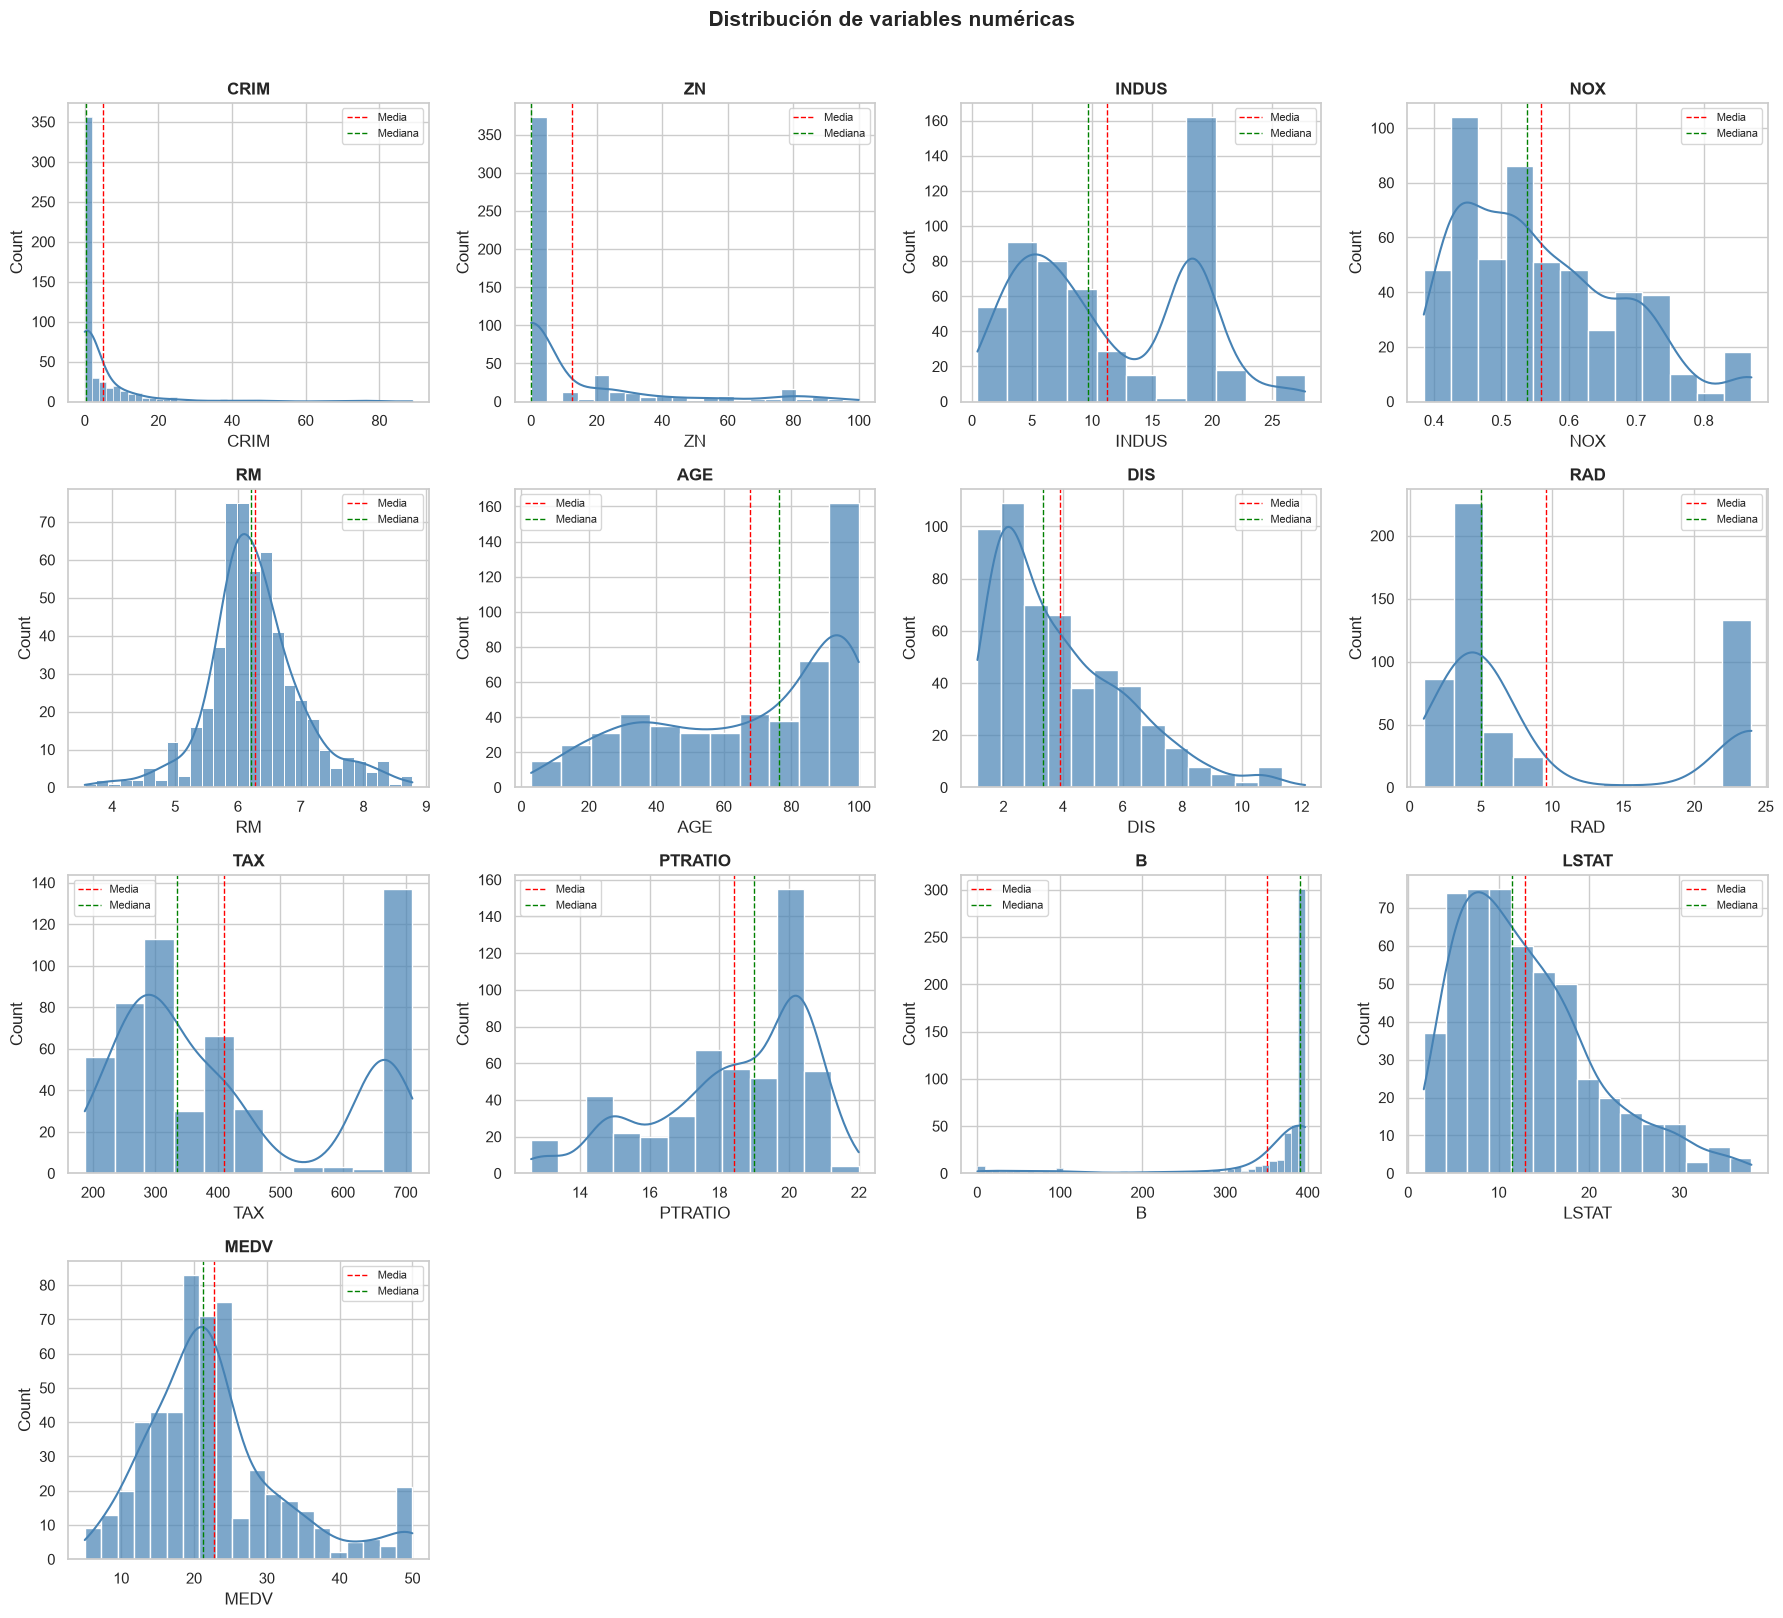

In [266]:
# Histogramas de todas las variables numéricas
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas + ['MEDV']):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Media')
    ax.axvline(df[col].median(), color='green', linestyle='--', linewidth=1, label='Mediana')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

for j in range(len(cols_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los histogramas confirman visualmente:

- **Sesgo positivo marcado (cola derecha larga):** CRIM, ZN, y en menor medida LSTAT y DIS. 
  La mayoría de las observaciones se concentra en valores bajos, con una cola de casos extremos 
  poco frecuentes — coincide con los valores de sesgo calculados antes (CRIM: 3.75, ZN: 1.96).

- **Sesgo negativo (cola izquierda):** B y AGE. En B, la mayoría de los valores se acumula cerca 
  del máximo, con pocos casos de valores bajos (sesgo: -2.40).

- **Distribución bimodal (dos grupos separados, sin observaciones intermedias):** RAD y TAX. Se 
  observan dos concentraciones claras: un grupo con valores bajos/medios y otro grupo grande 
  agrupado directamente en el valor máximo (RAD=24, TAX=666). Esto ya se había anticipado al revisar los percentiles de RAD (salto brusco entre la mediana y el percentil 75).

- **Distribución aproximadamente simétrica/campana:** RM es la que más se acerca a una distribución 
  normal (sesgo: 0.37).

- **MEDV (target):** presenta sesgo positivo moderado (1.06), con un pico marcado cerca de 50.
Esto es un posible indicio de que los valores de MEDV fueron truncados en 50.

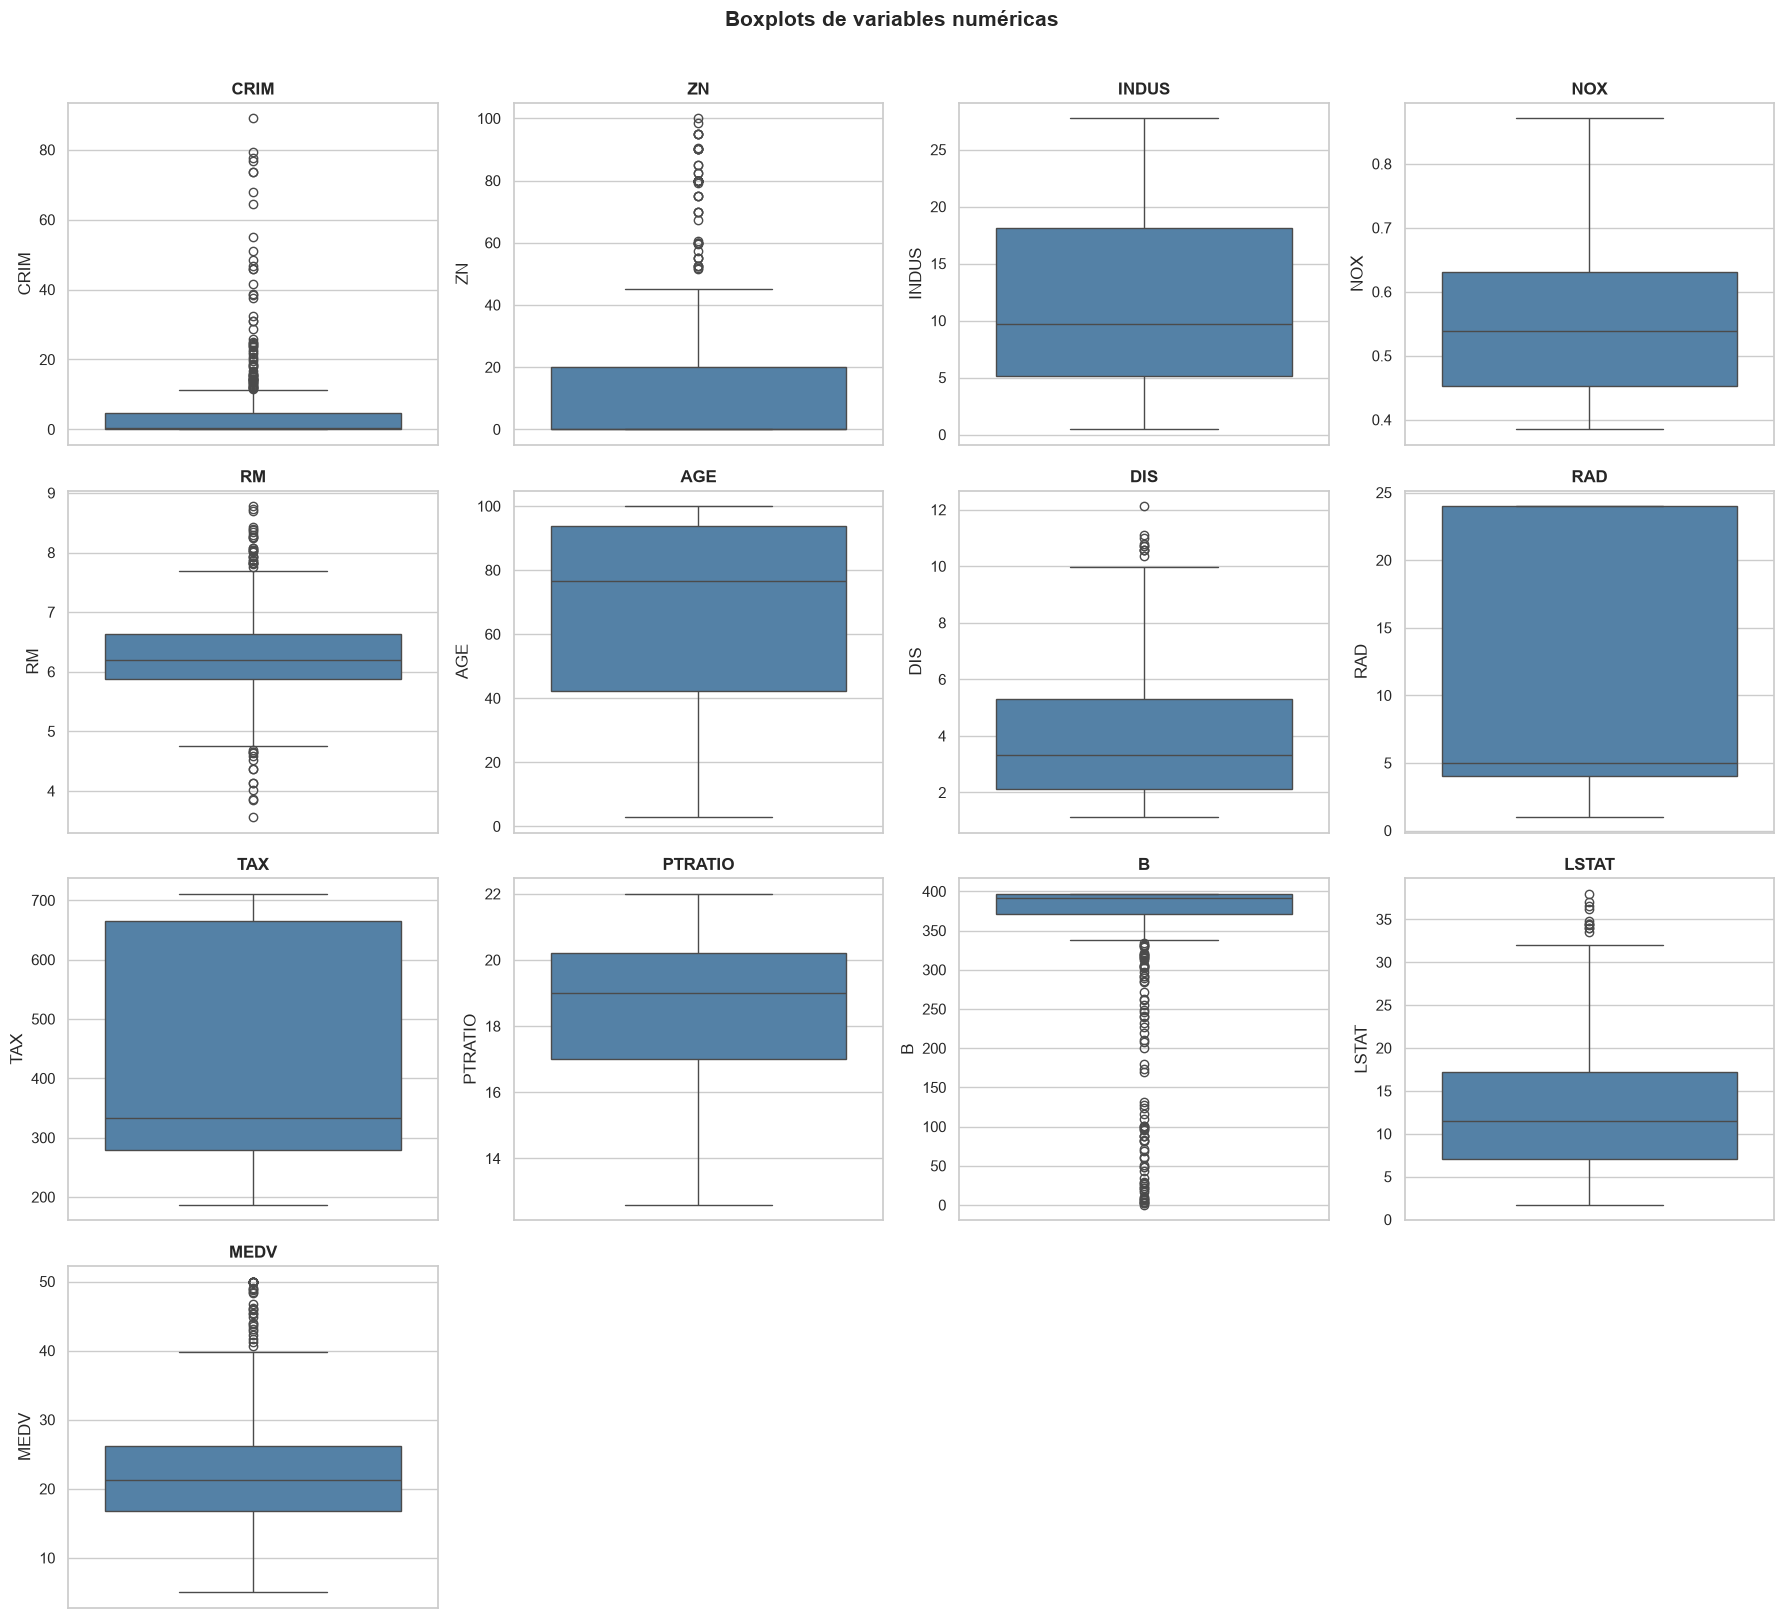

In [267]:
# Boxplots para detectar outliers
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas + ['MEDV']):
    ax = axes[i]
    sns.boxplot(y=df[col], ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')

for j in range(len(cols_numericas) + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots de variables numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Outliers

**Outliers:** se optó por no eliminar los outliers detectados con el método IQR, 
dado que en variables como CRIM y B corresponden a una subpoblación real (zonas de alta 
criminalidad), la misma identificada en el análisis de datos faltantes. Eliminarlos introduciría 
el mismo sesgo que se buscó evitar al imputar en lugar de eliminar los nulos.

Además, los outliers de ZN, RM, LSTAT y DIS, al igual que los de CRIM y B, corresponden a variación real 
del dataset (zonas con distintos perfiles urbanos), no a errores de carga.

El caso de MEDV es distinto: parte de sus outliers corresponden a valores truncados en 50, no representan necesariamente el precio real de esas zonas.
Es un límite de registro del dataset original. 
No se eliminan estas filas (se perdería información real de zonas caras).

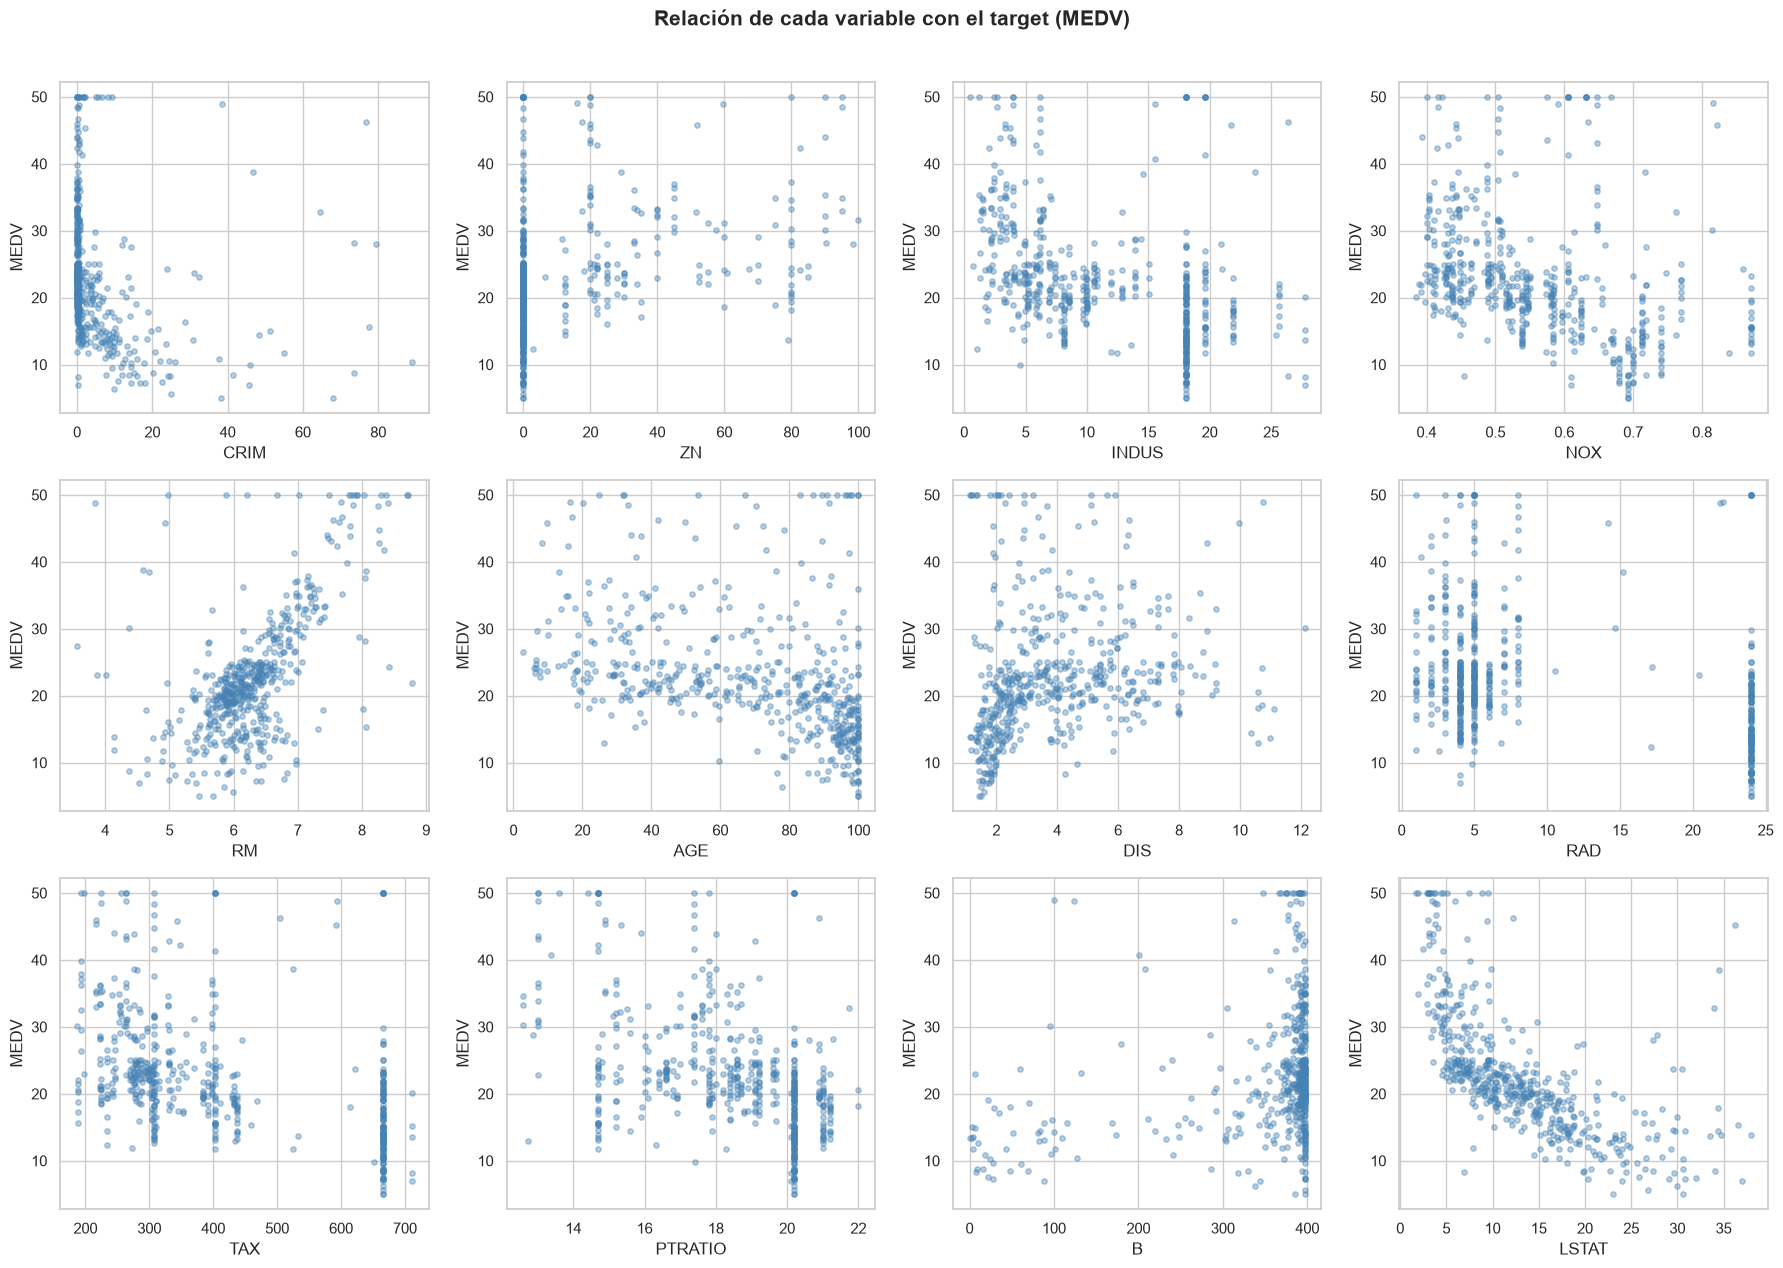

In [268]:
# Scatterplots de cada variable contra el target MEDV
# da una idea de qué variables tienen relación lineal fuerte con el precio (MEDV)
fig, axes = plt.subplots(4, 4, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    ax.scatter(df[col], df['MEDV'], alpha=0.4, s=15, color='steelblue')
    ax.set_xlabel(col)
    ax.set_ylabel('MEDV')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Relación de cada variable con el target (MEDV)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Patrones:

- **RM** muestra una relación positiva: a mayor número de habitaciones 
  promedio, mayor precio, tendencia ascendente bastante definida.
- **LSTAT** muestra una relación negativa marcada, pero con una forma curva: el precio cae fuerte para valores bajos de LSTAT y despues la caída se aplana. 
Esto sugiere que una transformación no lineal podría representar mejor esta relación.

- Variables como CRIM, DIS, CHAS y B se ven como nubes de puntos más dispersas, sin una tendencia lineal clara.

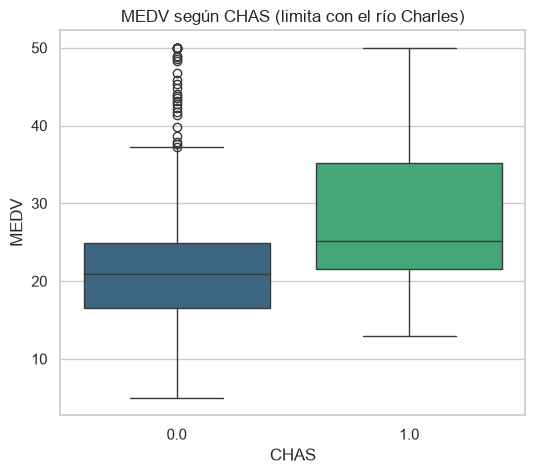

In [269]:
# MEDV según la variable dummy CHAS (para determinar si limitar con el río impacta en el precio)
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x=col_categorica, y='MEDV', palette='viridis')
plt.title('MEDV según CHAS (limita con el río Charles)')
plt.show()

El boxplot de MEDV según CHAS muestra que las zonas que limitan con el rio (CHAS=1) 
tienden a tener precios más altos (mediana 25.1) que las que no limitan (mediana 20.9). Sin 
embargo, el grupo CHAS=1 representa una fracción pequeña del dataset (45 filas)

---
## 3.6 Codificación de variables categóricas

**CHAS** es la única variable categórica del dataset y ya viene como dummy (0/1),
por lo tanto no requiere un encoding adicional.

---
## 3.7 Matriz de correlación

In [270]:
corr = df.corr(method='pearson')
corr.round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,0.01,0.34,0.15,0.37,-0.17,0.22,-0.18,0.53,0.48,0.25,-0.40,0.43,-0.23
ZN,0.01,1.00,-0.47,0.02,-0.45,0.26,-0.57,0.65,-0.29,-0.29,-0.35,0.12,-0.34,0.36
INDUS,0.34,-0.47,1.00,0.10,0.73,-0.36,0.60,-0.63,0.58,0.70,0.37,-0.32,0.54,-0.42
CHAS,0.15,0.02,0.10,1.00,0.12,-0.01,0.03,-0.04,0.01,-0.04,-0.11,-0.05,-0.00,0.21
NOX,0.37,-0.45,0.73,0.12,1.00,-0.27,0.67,-0.66,0.60,0.64,0.18,-0.39,0.56,-0.36
RM,-0.17,0.26,-0.36,-0.01,-0.27,1.00,-0.21,0.19,-0.22,-0.26,-0.33,0.14,-0.53,0.59
AGE,0.22,-0.57,0.60,0.03,0.67,-0.21,1.00,-0.73,0.43,0.49,0.25,-0.21,0.55,-0.39
DIS,-0.18,0.65,-0.63,-0.04,-0.66,0.19,-0.73,1.00,-0.46,-0.49,-0.23,0.19,-0.42,0.23
RAD,0.53,-0.29,0.58,0.01,0.60,-0.22,0.43,-0.46,1.00,0.88,0.46,-0.43,0.47,-0.35
TAX,0.48,-0.29,0.70,-0.04,0.64,-0.26,0.49,-0.49,0.88,1.00,0.44,-0.42,0.52,-0.44


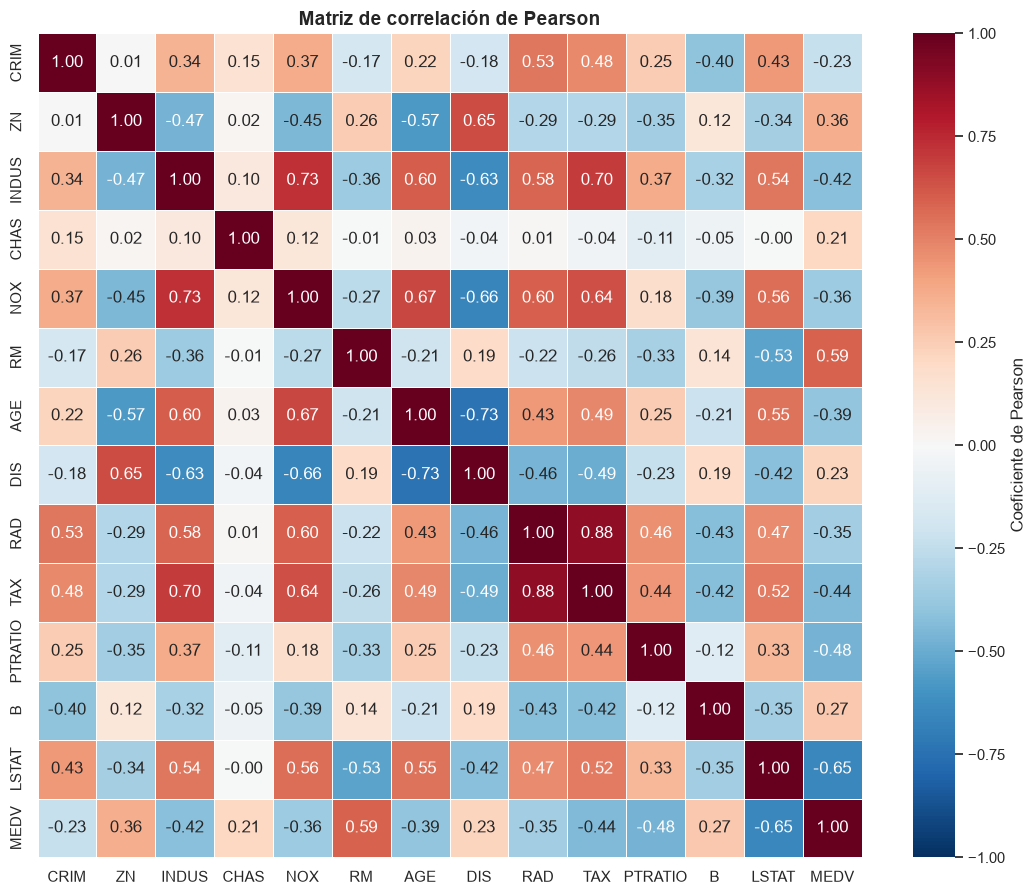

In [271]:


plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de Pearson'})
plt.title('Matriz de correlación de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Correlación con el target (MEDV):**

Las variables con correlación más fuerte con MEDV son LSTAT (r=-0.65) y RM (r=0.59), consistente 
con lo observado en los scatterplots de la sección anterior. Le siguen PTRATIO (r=-0.48), TAX 
(r=-0.44) e INDUS (r=-0.42) con correlación moderada. Variables como CRIM (r=-0.23), DIS (r=0.22) 
y CHAS (r=0.21) muestran correlación lineal débil con el precio, aunque esto no descarta que 
aporten valor predictivo de forma no lineal.

**Colinealidad:**

Se identificaron tres pares de variables con correlación fuerte entre sí (|r| >= 0.7):

- RAD y TAX (r=0.87): la más alta del dataset. Coincide con el patrón bimodal detectado antes en 
  ambas variables, que comparten el mismo subconjunto de zonas con RAD=24 y TAX=666.

- INDUS y NOX (r=0.73): zonas con más superficie industrial tienden a tener mayor concentración 
  de óxidos de nitrógeno.

- AGE y DIS (r=-0.72): zonas con viviendas más antiguas tienden a estar más cerca de los centros 
  de empleo.

Esta colinealidad es relevante porque la regresión lineal asume que los predictores son 
independientes entre sí.

---
## 3.8 Detección de outliers (método IQR)

In [272]:
cols_iqr = [c for c in df.columns if c != 'CHAS']

Q1 = df[cols_iqr].quantile(0.25)
Q3 = df[cols_iqr].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = ((df[cols_iqr] < limite_inferior) | (df[cols_iqr] > limite_superior)).sum()
porcentaje_outliers = (outliers / len(df) * 100).round(2)

print('Outliers por variable:')
print(outliers)
print()
print('Porcentaje de outliers por variable:')
print(porcentaje_outliers)

Outliers por variable:
CRIM       64
ZN         54
INDUS       0
NOX         0
RM         41
AGE         0
DIS        10
RAD         0
TAX         0
PTRATIO     0
B          86
LSTAT      11
MEDV       37
dtype: int64

Porcentaje de outliers por variable:
CRIM       12.03
ZN         10.15
INDUS       0.00
NOX         0.00
RM          7.71
AGE         0.00
DIS         1.88
RAD         0.00
TAX         0.00
PTRATIO     0.00
B          16.17
LSTAT       2.07
MEDV        6.95
dtype: float64


Se excluye CHAS de este análisis porque al ser una variable binaria el método IQR no es aplicable

Las variables con mayor proporción de outliers son B, CRIM y ZN, coherente con el sesgo marcado 
y la curtosis alta detectados en el análisis descriptivo para estas tres.

Como se justificó en la sección de datos faltantes, los outliers de CRIM y B corresponden a una 
subpoblación real del dataset (zonas de alta criminalidad), por lo que no se eliminan.

---
## 3.9 División train / test

**Nota:** para evitar data leakage, la imputación con KNN (decidida y 
justificada en la sección de datos faltantes) se aplica recién acá, **después** del split, 
ajustando el imputador únicamente con los datos de entrenamiento. Así el conjunto de 
test nunca influye en cómo se completan los valores faltantes de train, ni viceversa.

In [273]:
# Split ANTES de imputar y de estandarizar (evita data leakage en ambos pasos).
# nulos: se imputan recien despues de dividir el dataset

X = df[cols_numericas + [col_categorica]]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas')
print(f'Nulos en X_train: {X_train.isnull().sum().sum()} | Nulos en X_test: {X_test.isnull().sum().sum()}')
print(f'Nulos en y_train: {y_train.isnull().sum()} | Nulos en y_test: {y_test.isnull().sum()}')


Train: 425 filas | Test: 107 filas
Nulos en X_train: 67 | Nulos en X_test: 23
Nulos en y_train: 0 | Nulos en y_test: 0


In [274]:
from sklearn.preprocessing import RobustScaler

# Variables numericas continuas + target se imputan juntas con KNN
cols_num_target = cols_numericas + ['MEDV']

train_num_target = X_train[cols_numericas].copy()
train_num_target['MEDV'] = y_train

test_num_target = X_test[cols_numericas].copy()
test_num_target['MEDV'] = y_test

# Escalar (RobustScaler) fit solo con train
scaler_temp = RobustScaler()

train_scaled = pd.DataFrame(scaler_temp.fit_transform(train_num_target),columns=cols_num_target, index=train_num_target.index)

test_scaled = pd.DataFrame(scaler_temp.transform(test_num_target),columns=cols_num_target, index=test_num_target.index)



In [275]:
from sklearn.impute import KNNImputer

# Imputar con KNN - fit solo en train, transform en train y test
imputer = KNNImputer(n_neighbors=5)

train_imp_scaled = pd.DataFrame(imputer.fit_transform(train_scaled),columns=cols_num_target, index=train_num_target.index)

test_imp_scaled = pd.DataFrame(imputer.transform(test_scaled),columns=cols_num_target, index=test_num_target.index)


# Volver a la escala original (inverse_transform)
train_imputado = pd.DataFrame(scaler_temp.inverse_transform(train_imp_scaled),columns=cols_num_target, index=train_num_target.index)
test_imputado = pd.DataFrame(scaler_temp.inverse_transform(test_imp_scaled),columns=cols_num_target, index=test_num_target.index)

# Reemplazar en X_train/X_test/y_train/y_test los valores ya imputados
X_train[cols_numericas] = train_imputado[cols_numericas]
y_train = train_imputado['MEDV']

X_test[cols_numericas] = test_imputado[cols_numericas]
y_test = test_imputado['MEDV']


In [276]:
# CHAS varaible categorica, imputar con la moda
moda_chas_train = X_train['CHAS'].mode()[0]
X_train['CHAS'] = X_train['CHAS'].fillna(moda_chas_train)
X_test['CHAS'] = X_test['CHAS'].fillna(moda_chas_train)

In [277]:
# Verificacion de nulos

print('Nulos restantes - X_train:', X_train.isnull().sum().sum(), '| X_test:', X_test.isnull().sum().sum())
print('Nulos restantes - y_train:', y_train.isnull().sum(), '| y_test:', y_test.isnull().sum())


Nulos restantes - X_train: 0 | X_test: 0
Nulos restantes - y_train: 0 | y_test: 0


- Fit en train → transform en test: la información fluye en un solo sentido (train → test). Test nunca influye en nada que se use para procesar train (no leakage).
- Fit en train + test juntos (imputar/escalar antes del split): la información fluye en ambos sentidos. Un valor de test puede terminar afectando cómo se procesa una fila de train, y viceversa (leakage).

In [278]:
# Transformación logarítmica de CRIM y DIS (sesgo positivo). No elimina outliers solo comprime su escala.
# B se deja sin transformar: tiene sesgo negativo, y log empeora ese tipo de sesgo.

for col in ['CRIM', 'DIS']:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

# ZN: 73.5% de valores en 0 (zero-inflada), log1p mejora poco -> se deja sin transformar
# MEDV: es el target, se evaluará en la sección de modelado (punto 4), no acá


---
## 3.10 Estandarización de variables numéricas

Se utilizó StandardScaler (no RobustScaler) para este paso, ya que los modelos que se entrenan a 
continuación (regresión lineal, Ridge, Lasso) están calibrados asumiendo variables con media 0 y 
desvío estándar 1.

In [279]:
scaler = StandardScaler()

# Fit sobre sobre train, transform sobre train y test
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.describe().T[['mean', 'std']]  # verificación: media ~0, std ~1 en train

,mean,std
CRIM,5.851528e-17,1.001179
ZN,6.060512e-17,1.001179
INDUS,-7.941360e-17,1.001179
NOX,-1.128509e-16,1.001179
RM,1.797255e-16,1.001179
AGE,-1.086712e-16,1.001179
DIS,2.382408e-16,1.001179
RAD,-4.806613e-17,1.001179
TAX,1.065814e-16,1.001179
PTRATIO,1.329133e-15,1.001179


---
# Consigna 4:

## Implementar la solución del problema de regresión con regresión lineal múltiple.


Se decidió no eliminar los outliers de CRIM y B por corresponder a una subpoblación real del 
dataset. Sin embargo, dado que los modelos evaluados (LinearRegression, Ridge, Lasso, Elastic Net) 
minimizan el error cuadrático, son sensibles a la influencia desproporcionada de estos valores 
extremos sobre el ajuste. Esto se mitigó parcialmente aplicando log1p a CRIM

In [280]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

## 4.1 Método LinearRegression

In [281]:
# Entrenamiento
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

# Predicciones en ambos conjuntos
pred_train = modelo_lr.predict(X_train_scaled)
pred_test = modelo_lr.predict(X_test_scaled)

print('Metricas de train (regresion lineal)')
print('R²:', round(metrics.r2_score(y_train, pred_train), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train), 4))

print('Metricas de test (regresion lineal)')
print('R²:', round(metrics.r2_score(y_test, pred_test), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test), 4))

Metricas de train (regresion lineal)
R²: 0.6345
RMSE: 5.8378
MAE: 3.8796
Metricas de test (regresion lineal)
R²: 0.6042
RMSE: 5.417
MAE: 3.5711


- R² de train ≈ R² de test → modelo generaliza bien.
- R² de train >> R² de test → señal de overfitting.
- ambos son bajos → underfitting.

Con LinearRegression se obtuvo un fitting moderado.
No se observan señales de overfitting, las métricas de train y test son similares.

El modelo explica ~60-64% de la variabilidad de MEDV.
Esperable ya que se detectaron relaciones no lineales como la de LSTAT que un modelo lineal no puede capturar del todo.

MAE - Error Absoluto Medio, es el error promedio en dolares  

RMSE - Raíz del Error Cuadrático Medio, penaliza más los errores grandes que el MAE, porque los está elevando al cuadrado antes de promediar.  

- (RMSE=5.83 > MAE=3.57 en train)
- RMSE es bastante más grande que MAE, significa que hay algunas predicciones con error bastante grande que están inflando el RMSE más de lo que inflarían el MAE.



In [282]:
print(modelo_lr.coef_)

[ 1.45555564  0.814975   -0.0983053  -1.10214762  3.34261663 -1.74940881
 -3.09355538  0.72099827 -2.17806429 -1.81598632  0.79844545 -3.11448517
  1.55208652]


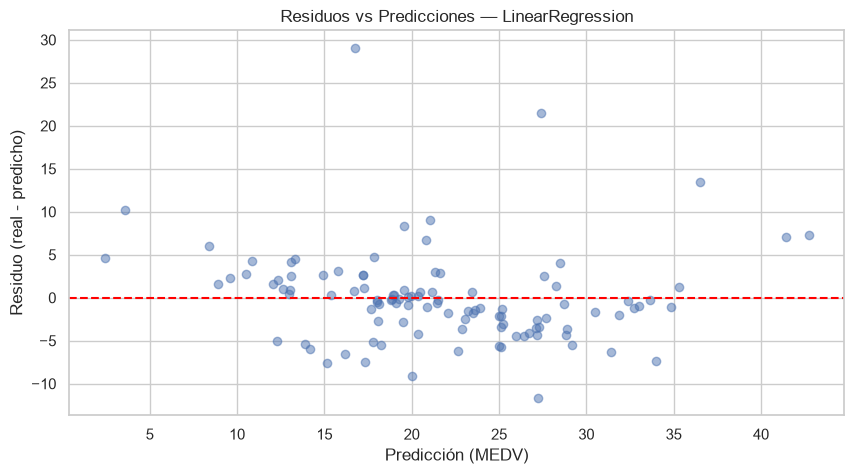

In [283]:
# grafico de residuos
residuos = y_test - pred_test

plt.figure(figsize=(10, 5))
plt.scatter(pred_test, residuos, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicción (MEDV)')
plt.ylabel('Residuo (real - predicho)')
plt.title('Residuos vs Predicciones — LinearRegression')
plt.show()

### Analisis de varaibles incluidas en el modelo

**Efecto de las variables con menor correlación con MEDV:**

- En la matriz de correlación CRIM (r=-0.23), CHAS (r=0.21), DIS (r=0.22) y B (r=0.27) fueron las variables con relación lineal más débil respecto al target. 

- Esto no significa que no aporten información al modelo pero igualmente decidimos ponerlas a prueba entrenando una regresión lineal sacando cada una de estas cuatro variables por separado y se compara el R², RMSE y MAE de test para medir el efecto de cada.

In [284]:
# Modelo sacando CRIM
X_train_sin_crim = X_train_scaled.drop(columns=['CRIM'])
X_test_sin_crim = X_test_scaled.drop(columns=['CRIM'])

modelo_sin_crim = LinearRegression()
modelo_sin_crim.fit(X_train_sin_crim, y_train)

pred_train_sin_crim = modelo_sin_crim.predict(X_train_sin_crim)
pred_test_sin_crim = modelo_sin_crim.predict(X_test_sin_crim)

print('Metricas de train (sin CRIM)')
print('R²:', round(metrics.r2_score(y_train, pred_train_sin_crim), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_sin_crim)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_sin_crim)), 4)

print('Metricas de test (sin CRIM)')
print('R²:', round(metrics.r2_score(y_test, pred_test_sin_crim), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_sin_crim)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_sin_crim), 4))

Metricas de train (sin CRIM)
R²: 0.6296
RMSE: 5.8772
MAE: 4 4
Metricas de test (sin CRIM)
R²: 0.5727
RMSE: 5.628
MAE: 3.6428


In [285]:
# Modelo sacando CHAS
X_train_sin_chas = X_train_scaled.drop(columns=['CHAS'])
X_test_sin_chas = X_test_scaled.drop(columns=['CHAS'])

modelo_sin_chas = LinearRegression()
modelo_sin_chas.fit(X_train_sin_chas, y_train)

pred_train_sin_chas = modelo_sin_chas.predict(X_train_sin_chas)
pred_test_sin_chas = modelo_sin_chas.predict(X_test_sin_chas)

print('Metricas de train (sin CHAS)')
print('R²:', round(metrics.r2_score(y_train, pred_train_sin_chas), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_sin_chas)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_sin_chas), 4))

print('Metricas de test (sin CHAS)')
print('R²:', round(metrics.r2_score(y_test, pred_test_sin_chas), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_sin_chas)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_sin_chas), 4))

Metricas de train (sin CHAS)
R²: 0.6117
RMSE: 6.0175
MAE: 3.9783
Metricas de test (sin CHAS)
R²: 0.5938
RMSE: 5.4878
MAE: 3.7041


In [286]:
# Modelo sacando DIS
X_train_sin_dis = X_train_scaled.drop(columns=['DIS'])
X_test_sin_dis = X_test_scaled.drop(columns=['DIS'])

modelo_sin_dis = LinearRegression()
modelo_sin_dis.fit(X_train_sin_dis, y_train)

pred_train_sin_dis = modelo_sin_dis.predict(X_train_sin_dis)
pred_test_sin_dis = modelo_sin_dis.predict(X_test_sin_dis)

print('Metricas de train (sin DIS)')
print('R²:', round(metrics.r2_score(y_train, pred_train_sin_dis), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_sin_dis)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_sin_dis), 4))

print('Metricas de test (sin DIS)')
print('R²:', round(metrics.r2_score(y_test, pred_test_sin_dis), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_sin_dis)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_sin_dis), 4))

Metricas de train (sin DIS)
R²: 0.608
RMSE: 6.046
MAE: 4.0545
Metricas de test (sin DIS)
R²: 0.5692
RMSE: 5.6512
MAE: 3.8546


In [287]:
# Modelo sacando B
X_train_sin_b = X_train_scaled.drop(columns=['B'])
X_test_sin_b = X_test_scaled.drop(columns=['B'])

modelo_sin_b = LinearRegression()
modelo_sin_b.fit(X_train_sin_b, y_train)

pred_train_sin_b = modelo_sin_b.predict(X_train_sin_b)
pred_test_sin_b = modelo_sin_b.predict(X_test_sin_b)

print('Metricas de train (sin B)')
print('R²:', round(metrics.r2_score(y_train, pred_train_sin_b), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_sin_b)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_sin_b), 4))

print('Metricas de test (sin B)')
print('R²:', round(metrics.r2_score(y_test, pred_test_sin_b), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_sin_b)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_sin_b), 4))

Metricas de train (sin B)
R²: 0.63
RMSE: 5.8736
MAE: 3.9475
Metricas de test (sin B)
R²: 0.5851
RMSE: 5.5461
MAE: 3.6625


In [288]:
# Regresión lineal sacando CRIM, CHAS, DIS y B
X_train_reducido = X_train_scaled.drop(columns=['CRIM', 'CHAS', 'DIS', 'B'])
X_test_reducido = X_test_scaled.drop(columns=['CRIM', 'CHAS', 'DIS', 'B'])

modelo_lr_reducido = LinearRegression()
modelo_lr_reducido.fit(X_train_reducido, y_train)

# Predicciones
pred_train_reducido = modelo_lr_reducido.predict(X_train_reducido)
pred_test_reducido = modelo_lr_reducido.predict(X_test_reducido)

print('Metricas de train (regresion lineal sin CRIM, CHAS, DIS, B)')
print('R²:', round(metrics.r2_score(y_train, pred_train_reducido), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_reducido)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_reducido), 4))

print('Metricas de test (regresion lineal sin CRIM, CHAS, DIS, B)')
print('R²:', round(metrics.r2_score(y_test, pred_test_reducido), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_reducido)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_reducido), 4))

Metricas de train (regresion lineal sin CRIM, CHAS, DIS, B)
R²: 0.5745
RMSE: 6.2986
MAE: 4.2102
Metricas de test (regresion lineal sin CRIM, CHAS, DIS, B)
R²: 0.5303
RMSE: 5.9012
MAE: 3.8819


- Sacar cualquiera de estas variables empeora el modelo. 

- A pesar de tener la correlación lineal más baja con MEDV, las cuatro aportan información.

- Sacando las cuatro juntas, el efecto se acumula y no conviene eliminarlas del modelo final.

## 4.2 Métodos de gradiente descendente

Elegimos hacer Gradiente decendiente y no el estocástico ni el mini batch ya que con el gradiente decendiente común es suficiente. Esas otras varaintes pueden ser mejor para datasets más grandes. Además, el estocástico y el mini batch meten ruido en la curva de pérdida vs época.

In [289]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    Entrena un modelo de regresión lineal mediante Gradient Descent.
    Ajusta los pesos W de un modelo lineal y_pred = X @ W usando el
    Error Cuadrático Medio (MSE) como función de costo.

    Retorna
    -------
    np.ndarray
        Vector de pesos W, forma (m + 1, 1), incluyendo el bias.
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Columna de unos para el bias
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))

    # Inicializar pesos aleatorios
    W = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2 / n * grad_sum
        gradient = np.transpose(grad_mul).reshape(-1, 1)
        W = W - (lr * gradient)

    # Gráfico de loss vs epochs
    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de validación')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    plt.show()

    return W

In [290]:
np.random.seed(RANDOM_STATE)  # reproducibilidad de la inicialización de W

X_train_np = X_train_scaled.to_numpy()
X_test_np = X_test_scaled.to_numpy()
y_train_np = y_train.to_numpy().reshape(-1, 1)
y_test_np = y_test.to_numpy().reshape(-1, 1)

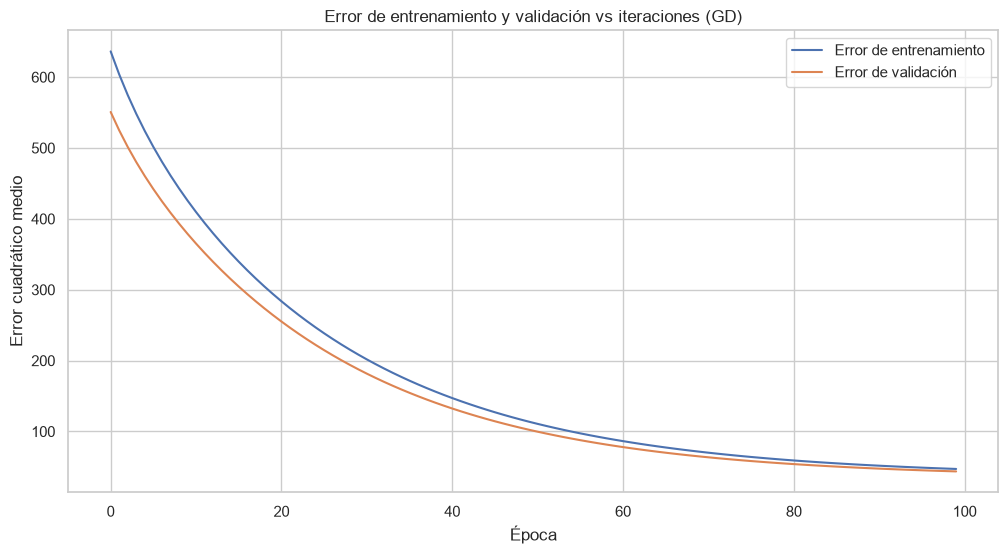

In [291]:
# Se usan los hiperparámetros por defecto de la función, sin ajustar nada todavía
# se hace en el punto 5.
np.random.seed(RANDOM_STATE) 
W_gd = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.01, epochs=100)

In [292]:
print(W_gd)
# Estos son los pesos que apendió el modelo, el primero es el bias (el precio base cuando todas 
# las varaibles estan en su promedio porque estan estandarizadas)
# 
# los otros son los coeficientes de cada varaible

[[ 2.00720225e+01]
 [ 1.14312993e-01]
 [ 8.82305853e-01]
 [ 4.38774412e-01]
 [-6.35782405e-01]
 [ 3.16703342e+00]
 [ 1.38967345e-02]
 [-3.41277999e-01]
 [-2.42622259e-01]
 [-4.11726219e-01]
 [-1.94348317e+00]
 [ 5.00396438e-01]
 [-2.74181988e+00]
 [ 1.31492299e+00]]


In [293]:
X_train_b = np.hstack([np.ones((X_train_np.shape[0], 1)), X_train_np])
X_test_b = np.hstack([np.ones((X_test_np.shape[0], 1)), X_test_np])
pred_train_gd = (X_train_b @ W_gd).ravel()
pred_test_gd = (X_test_b @ W_gd).ravel()

print('Métricas de train (Gradient Descent)')
print('R²:', round(metrics.r2_score(y_train, pred_train_gd), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_train, pred_train_gd)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_train, pred_train_gd), 4))

print('Métricas de test (Gradient Descent)')
print('R²:', round(metrics.r2_score(y_test, pred_test_gd), 4))
print('RMSE:', round(np.sqrt(metrics.mean_squared_error(y_test, pred_test_gd)), 4))
print('MAE:', round(metrics.mean_absolute_error(y_test, pred_test_gd), 4))

Métricas de train (Gradient Descent)
R²: 0.4992
RMSE: 6.8335
MAE: 4.4025
Métricas de test (Gradient Descent)
R²: 0.416
RMSE: 6.5796
MAE: 4.078


In [294]:
comparacion = pd.DataFrame({
    'Variable': ['bias'] + cols_numericas + [col_categorica],
    'GD': W_gd.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})

comparacion['Diferencia'] = (comparacion['GD'] - comparacion['LinearRegression']).round(3)

comparacion

,Variable,GD,LinearRegression,Diferencia
0,bias,20.072,23.065,-2.993
1,CRIM,0.114,1.456,-1.342
2,ZN,0.882,0.815,0.067
3,INDUS,0.439,-0.098,0.537
4,NOX,-0.636,-1.102,0.466
5,RM,3.167,3.343,-0.176
6,AGE,0.014,-1.749,1.763
7,DIS,-0.341,-3.094,2.753
8,RAD,-0.243,0.721,-0.964
9,TAX,-0.412,-2.178,1.766


- Con los hiperparámetros por defecto (lr=0.01, epochs=100), el gradiente
descendiente no llega a converger
- el R² de test da ≈0.57, peor que LinearRegression (≈0.64), y el gráfico de loss vs epochs
muestra que la curva de loss todavía está bajando cuando se corta en la
época 100
- Los pesos difieren de LinearRegression

Esto sugiere que lr=0.01 es demasiado chico y/o epochs=100 es insuficiente para esa tasa de aprendizaje (lr). 

En el punto 5 se explora un barrido de hiperparámetros.

## 4.3 Métodos de regularización (Ridge, Lasso, Elastic Net)

- Probamos los tres métodos de regularización, con un alpha elegido a mano.  

- Usamos X_train_scaled (x train escalado) porque estos métodos penalizan la magnitud de los coeficientes y eso es comparable entre variables solo si están en la misma escala.

In [295]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# alpha elegido a mano
lasso = Lasso(alpha=0.01)
ridge = Ridge(alpha=0.1)
elasticnet = ElasticNet(alpha=0.01, l1_ratio=0.5)

lasso.fit(X_train_scaled, y_train)
ridge.fit(X_train_scaled, y_train)
elasticnet.fit(X_train_scaled, y_train)

print('Ridge score (train):', ridge.score(X_train_scaled, y_train))
print('Lasso score (train):', lasso.score(X_train_scaled, y_train))
print('ElasticNet score (train):', elasticnet.score(X_train_scaled, y_train))

Ridge score (train): 0.6345150049610652
Lasso score (train): 0.6344705970457991
ElasticNet score (train): 0.6344296870707874


Con los alphas elegidos a mano (0.01/0.1), los tres modelos dan un
resultado muy similar a LinearRegression (R²=0.63 en train).

In [296]:
comparacion_coefs = pd.DataFrame({
    'Variable': cols_numericas + [col_categorica],
    'Ridge': ridge.coef_.round(3),
    'Lasso': lasso.coef_.round(3),
    'ElasticNet': elasticnet.coef_.round(3),
    'LinearRegression': modelo_lr.coef_.round(3)
})
comparacion_coefs

,Variable,Ridge,Lasso,ElasticNet,LinearRegression
0,CRIM,1.453,1.406,1.384,1.456
1,ZN,0.814,0.797,0.793,0.815
2,INDUS,-0.099,-0.102,-0.121,-0.098
3,NOX,-1.101,-1.062,-1.049,-1.102
4,RM,3.342,3.343,3.333,3.343
5,AGE,-1.748,-1.723,-1.703,-1.749
6,DIS,-3.090,-3.021,-2.983,-3.094
7,RAD,0.719,0.645,0.637,0.721
8,TAX,-2.174,-2.080,-2.042,-2.178
9,PTRATIO,-1.816,-1.802,-1.803,-1.816


Con estos alphas (chicos), los coeficientes de los tres modelos regularizados
son muy parecidos a los de LinearRegression, la penalización es leve.  

Lasso no descartó ninguna variable (ningún coeficiente en 0), lo cual es
esperable con un alpha tan chico como 0.01.

## 4.4 Obtener las métricas adecuadas tanto para entrenamiento como para prueba.

**Métricas elegidas: R², RMSE y MAE.**

- **R²** indica qué proporción de la variabilidad de MEDV explica el modelo, es más directa para responder si es buen fitting.
- **RMSE** penaliza más los errores grandes (por el cuadrado)
- **MAE** es más robusto a outliers. 
- Comparar ambas permite detectar si hay pocas predicciones malas dominando el error (si RMSE >> MAE, es señal de eso).

**Se descartan MSE y MAPE:**
- **MSE** da la misma información que RMSE pero en unidades al cuadrado, menos interpretable.
- **MAPE** pondera los errores en términos porcentuales. Un mismo error en dólares pesa más porcentualmente en las casas baratas que en las caras.

In [297]:
def calcular_metricas(y_true, y_pred):
    r2 = metrics.r2_score(y_true, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_true, y_pred))
    mae = metrics.mean_absolute_error(y_true, y_pred)
    return r2, rmse, mae

# Predicciones ya calculadas
modelos_pred = {
    'LinearRegression': (pred_train, pred_test),
    'Gradient Descent': (pred_train_gd, pred_test_gd),
    'Ridge': (ridge.predict(X_train_scaled), ridge.predict(X_test_scaled)),
    'Lasso': (lasso.predict(X_train_scaled), lasso.predict(X_test_scaled)),
    'ElasticNet': (elasticnet.predict(X_train_scaled), elasticnet.predict(X_test_scaled)),
}

filas = []
for nombre, (pt, pte) in modelos_pred.items():
    r2_tr, rmse_tr, mae_tr = calcular_metricas(y_train, pt)
    r2_te, rmse_te, mae_te = calcular_metricas(y_test, pte)
    filas.append({
        'Modelo': nombre,
        'R² train': round(r2_tr, 4), 'R² test': round(r2_te, 4),
        'RMSE train': round(rmse_tr, 4), 'RMSE test': round(rmse_te, 4),
        'MAE train': round(mae_tr, 4), 'MAE test': round(mae_te, 4),
    })

df_metricas = pd.DataFrame(filas)
df_metricas

,Modelo,R² train,R² test,RMSE train,RMSE test,MAE train,MAE test
0,LinearRegression,0.6345,0.6042,5.8378,5.4170,3.8796,3.5711
1,Gradient Descent,0.4992,0.4160,6.8335,6.5796,4.4025,4.0780
2,Ridge,0.6345,0.6041,5.8378,5.4176,3.8795,3.5708
3,Lasso,0.6345,0.6020,5.8382,5.4316,3.8773,3.5666
4,ElasticNet,0.6344,0.6014,5.8385,5.4357,3.8763,3.5626


La métrica de train sola no dice si el modelo generaliza 
- un modelo puede ajustar perfecto los datos que ya vio y fallar con datos nuevos (overfitting).

- **Train ≈ Test:** el modelo generaliza bien.
- **Train >> Test:** señal de overfitting, el modelo memorizó el ruido de entrenamiento.
- **Ambas malas:** underfitting, el modelo es demasiado simple para el problema.

En este caso, la similitud entre train y test en LinearRegression, Ridge, Lasso y ElasticNet confirma que no hay overfitting. 
 
Gradient Descent es la excepción en esta tabla porque corresponde a la versión sin optimizar de  (lr=0.01).

## 5.1 Variar los hiperparámetros de gradiente descendente.

En 4.2 usamos los valores por defecto (lr=0.01, epochs=100) que no llegaban a converger (R² test≈0.57). Acá probamos manualmente otras combinaciones para ver el efecto de cada hiperparámetro.


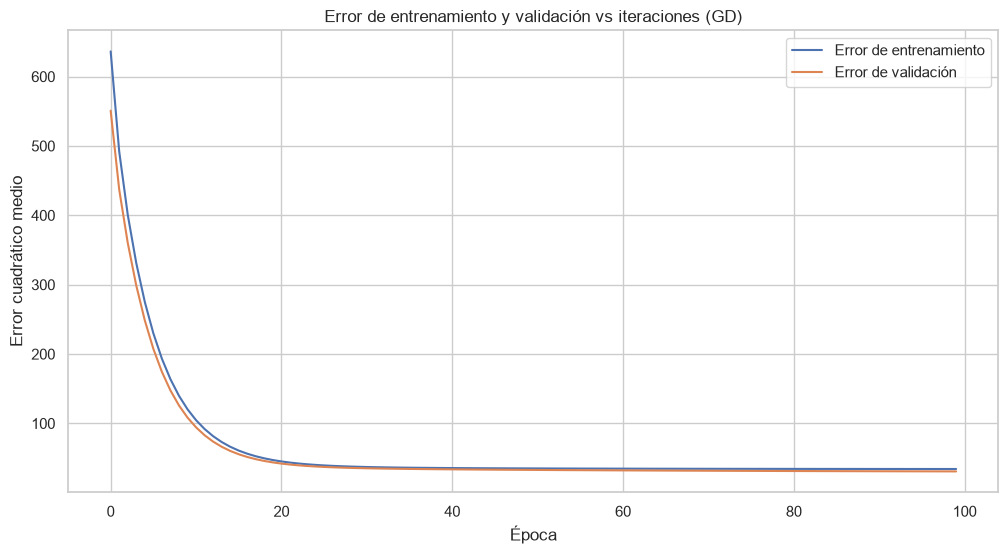

lr=0.05, epochs=100 | R² test: 0.5851


In [298]:
# Intento 1: subimos lr
np.random.seed(RANDOM_STATE) 
W_prueba1 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=100)
pred_test_prueba1 = (X_test_b @ W_prueba1).ravel()
print('lr=0.05, epochs=100 | R² test:', round(metrics.r2_score(y_test, pred_test_prueba1), 4))

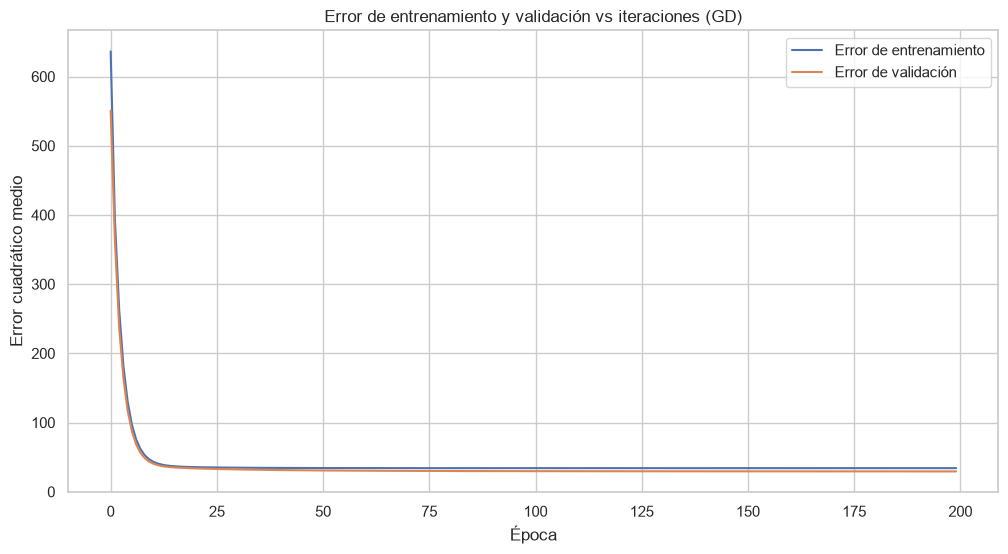

lr=0.1, epochs=200 | R² test: 0.6035


In [299]:
# Intento 2: lr más alto, más epochs
np.random.seed(RANDOM_STATE) 
W_prueba2 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.1, epochs=200)
pred_test_prueba2 = (X_test_b @ W_prueba2).ravel()
print('lr=0.1, epochs=200 | R² test:', round(metrics.r2_score(y_test, pred_test_prueba2), 4))

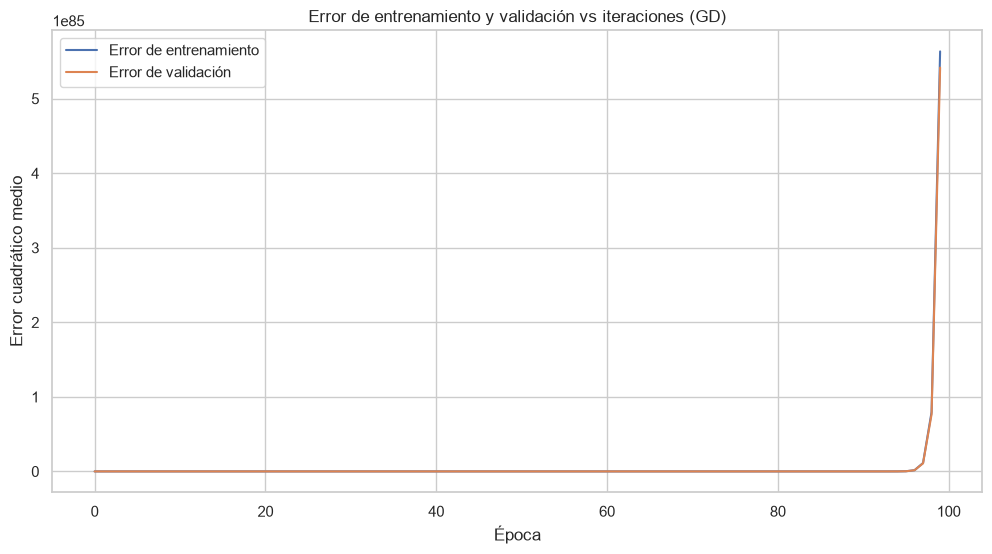

lr=0.3, epochs=100 | R² test: -5.165687277089265e+84


In [300]:
# Intento 3: lr demasiado alto
np.random.seed(RANDOM_STATE) 
W_prueba3 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.3, epochs=100)
pred_test_prueba3 = (X_test_b @ W_prueba3).ravel()
print('lr=0.3, epochs=100 | R² test:', metrics.r2_score(y_test, pred_test_prueba3))

Subir el lr mejora la convergencia
- con lr=0.05 obtiene un R²=0,5851
- con lr=0.1 se observa que el R² alcanza el de LinearRegression
- pasado cierto punto (lr=0.3), el modelo **diverge** en vez de mejorar, los pasos son muy grandes


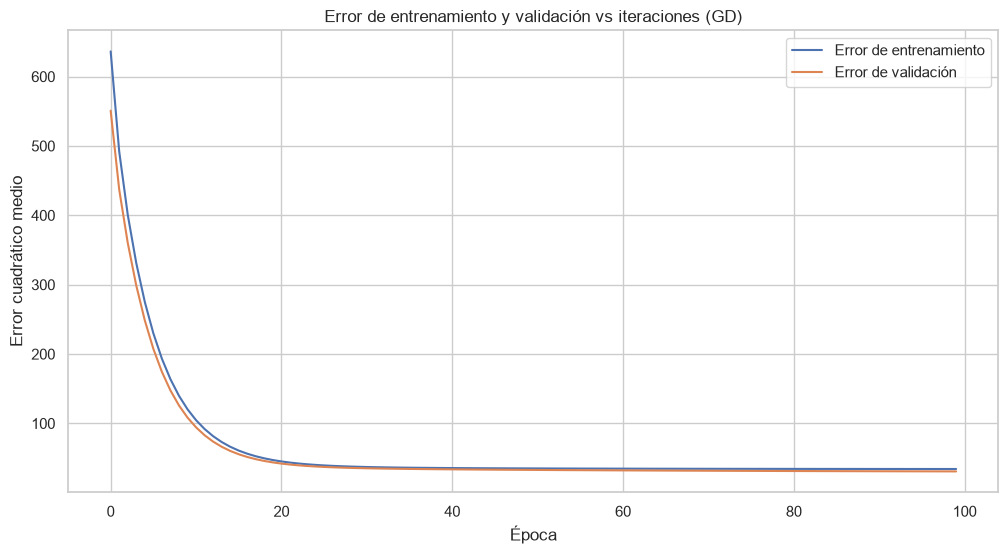

In [301]:
# lr=0.05 epochs=100
np.random.seed(RANDOM_STATE)
W_gd = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=100)


In [302]:
comparacion = pd.DataFrame({
    'Variable': ['bias'] + cols_numericas + [col_categorica],
    'GD': W_gd.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})

comparacion['Diferencia'] = (comparacion['GD'] - comparacion['LinearRegression']).round(3)

comparacion

,Variable,GD,LinearRegression,Diferencia
0,bias,23.064,23.065,-0.001
1,CRIM,1.183,1.456,-0.273
2,ZN,0.687,0.815,-0.128
3,INDUS,-0.155,-0.098,-0.057
4,NOX,-0.933,-1.102,0.169
5,RM,3.357,3.343,0.014
6,AGE,-1.453,-1.749,0.296
7,DIS,-2.514,-3.094,0.580
8,RAD,0.359,0.721,-0.362
9,TAX,-1.470,-2.178,0.708


Con lr=0.05 las métricas de las dos versiones son prácticamente idénticas
(R² test =0.63-0.634 en ambas), pero la tabla de pesos muestra que con 100
épocas varios coeficientes todavía están lejos del valor de LinearRegression
(DIS, TAX, CRIM difieren en 0.5-0.6)

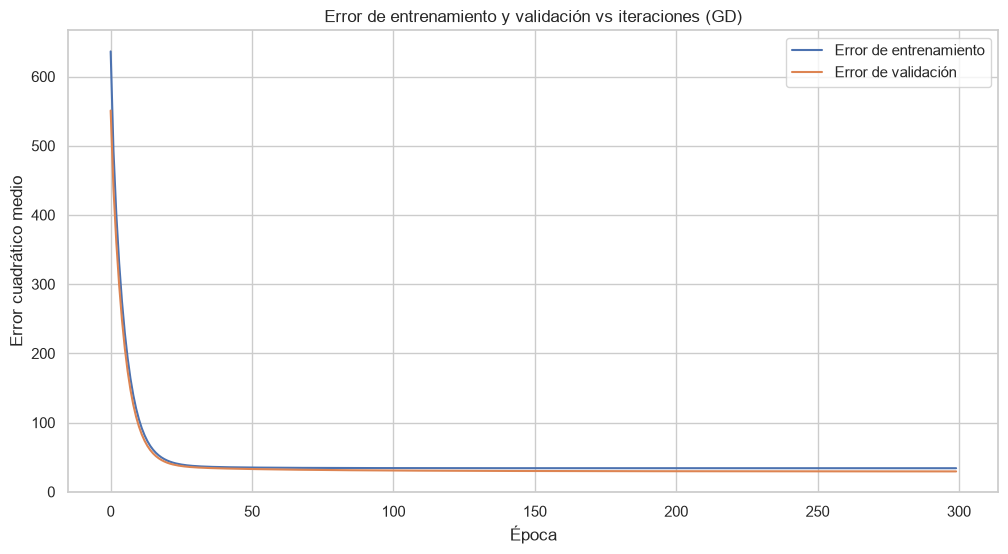

In [303]:
# aumento epocas = 300
np.random.seed(RANDOM_STATE)
W_gd_300 = gradient_descent(X_train_np, y_train_np, X_test_np, y_test_np, lr=0.05, epochs=300)

In [304]:
comparacion_300 = pd.DataFrame({
    'Variable': ['bias'] + cols_numericas + [col_categorica],
    'GD (300 epochs)': W_gd_300.ravel().round(3),
    'LinearRegression': [round(modelo_lr.intercept_, 3)] + list(modelo_lr.coef_.round(3))
})
comparacion_300['Diferencia'] = (comparacion_300['GD (300 epochs)'] - comparacion_300['LinearRegression']).round(3)
comparacion_300

,Variable,GD (300 epochs),LinearRegression,Diferencia
0,bias,23.065,23.065,0.000
1,CRIM,1.462,1.456,0.006
2,ZN,0.802,0.815,-0.013
3,INDUS,-0.133,-0.098,-0.035
4,NOX,-1.096,-1.102,0.006
5,RM,3.340,3.343,-0.003
6,AGE,-1.744,-1.749,0.005
7,DIS,-3.085,-3.094,0.009
8,RAD,0.638,0.721,-0.083
9,TAX,-2.081,-2.178,0.097


In [305]:
pred_test_300 = (X_test_b @ W_gd_300).ravel()
print('GD (300 epochs) | R² test:', round(metrics.r2_score(y_test, pred_test_300), 4))

GD (300 epochs) | R² test: 0.6024


mientras que con 300 épocas esas diferencias se reducen. 
- Esto confirma que la colinealidad entre variables (RAD-TAX, r=0.87) genera una zona relativamente "plana" en la función de costo: las predicciones ya son buenas con pocas épocas, pero los pesos individuales necesitan más iteraciones para asentarse en el mismo punto
que la solución analítica (regresion lineal)

In [306]:
# nos quedamos con la versión de 300 épocas
W_gd = W_gd_300
pred_train_gd = (X_train_b @ W_gd).ravel()
pred_test_gd = (X_test_b @ W_gd).ravel()

## 5.2 Variar los hiperparámetros de Lasso y Ridge

En 4.3 usamos alphas elegidos a mano y chicos (Ridge=0.1, Lasso=0.01), que dieron
un resultado muy similar a LinearRegression. Acá probamos manualmente otros
valores, más grandes, para ver si el modelo mejora o empeora.

In [307]:
# Intento 1 (Ridge): alpha más alto que en 4.3
ridge_prueba1 = Ridge(alpha=1)
ridge_prueba1.fit(X_train_scaled, y_train)
pred_test_ridge1 = ridge_prueba1.predict(X_test_scaled)
print('Ridge alpha=1 | R² test:', round(metrics.r2_score(y_test, pred_test_ridge1), 4))

Ridge alpha=1 | R² test: 0.6034


In [308]:
# Intento 2 (Ridge): alpha bastante más alto
ridge_prueba2 = Ridge(alpha=10)
ridge_prueba2.fit(X_train_scaled, y_train)
pred_test_ridge2 = ridge_prueba2.predict(X_test_scaled)
print('Ridge alpha=10 | R² test:', round(metrics.r2_score(y_test, pred_test_ridge2), 4))

Ridge alpha=10 | R² test: 0.5968


In [309]:
# Intento 3 (Ridge): alpha bastante más alto todavía
ridge_prueba3 = Ridge(alpha=50)
ridge_prueba3.fit(X_train_scaled, y_train)
pred_test_ridge3 = ridge_prueba3.predict(X_test_scaled)
print('Ridge alpha=50 | R² test:', round(metrics.r2_score(y_test, pred_test_ridge3), 4))

Ridge alpha=50 | R² test: 0.5761


In [310]:
# Intento 1 (Lasso): alpha más alto que en 4.3
lasso_prueba1 = Lasso(alpha=0.05)
lasso_prueba1.fit(X_train_scaled, y_train)
pred_test_lasso1 = lasso_prueba1.predict(X_test_scaled)
print('Lasso alpha=0.05 | R² test:', round(metrics.r2_score(y_test, pred_test_lasso1), 4),
      '| variables descartadas:', (lasso_prueba1.coef_ == 0).sum())

Lasso alpha=0.05 | R² test: 0.5921 | variables descartadas: 0


In [311]:
# Intento 1 (Lasso): alpha más alto que en 4.3
lasso_prueba1 = Lasso(alpha=0.05)
lasso_prueba1.fit(X_train_scaled, y_train)
pred_test_lasso1 = lasso_prueba1.predict(X_test_scaled)
print('Lasso alpha=0.05 | R² test:', round(metrics.r2_score(y_test, pred_test_lasso1), 4),
      '| variables descartadas:', (lasso_prueba1.coef_ == 0).sum())

Lasso alpha=0.05 | R² test: 0.5921 | variables descartadas: 0


In [312]:
# Intento 3 (Lasso): alpha demasiado alto
lasso_prueba3 = Lasso(alpha=1)
lasso_prueba3.fit(X_train_scaled, y_train)
pred_test_lasso3 = lasso_prueba3.predict(X_test_scaled)
print('Lasso alpha=1 | R² test:', round(metrics.r2_score(y_test, pred_test_lasso3), 4),
      '| variables descartadas:', (lasso_prueba3.coef_ == 0).sum())

Lasso alpha=1 | R² test: 0.4795 | variables descartadas: 7


Subir el alpha no empeora el modelo, tanto Ridge como Lasso mejoran levemente hasta un cierto punto.

Pasado ese punto empiezan a empeorar:
- en Lasso empieza a descartar variables que sí aportaban información (underfitting)
- Ridge tolera alphas más grandes, su caída es más gradual. 

- Nos quedamos con el alpha que dio mejor R² test de cada uno como configuración final

In [313]:
# Nos quedamos con los mejores alphas encontrados
ridge = ridge_prueba3  
lasso = lasso_prueba1  

## 6. Comparación de modelos


Se comparan los 5 modelos usando las métricas R², RMSE,
MAE, calculadas sobre test.  

Se usan las versiones finales de cada modelo:
- LinearRegression (4.1), 
- Gradient Descent optimizado (5.1)
- Ridge/Lasso/ElasticNet con los mejores hiperparámetros encontrados (5.2)

In [314]:
# Predicciones de cada modelo despues del ajuste de hiperparámetros
modelos_finales = {
    'LinearRegression': (pred_train, pred_test),
    'Gradient Descent': (pred_train_gd, pred_test_gd),
    'Ridge': (ridge.predict(X_train_scaled), ridge.predict(X_test_scaled)),
    'Lasso': (lasso.predict(X_train_scaled), lasso.predict(X_test_scaled)),
    'ElasticNet': (elasticnet.predict(X_train_scaled), elasticnet.predict(X_test_scaled)),
}

filas = []
for nombre, (pt, pte) in modelos_finales.items():
    r2_tr, rmse_tr, mae_tr = calcular_metricas(y_train, pt)
    r2_te, rmse_te, mae_te = calcular_metricas(y_test, pte)
    filas.append({
        'Modelo': nombre,
        'R² train': round(r2_tr, 4), 'R² test': round(r2_te, 4),
        'RMSE train': round(rmse_tr, 4), 'RMSE test': round(rmse_te, 4),
        'MAE train': round(mae_tr, 4), 'MAE test': round(mae_te, 4),
    })

df_comparacion_final = pd.DataFrame(filas).sort_values('RMSE test')
df_comparacion_final

,Modelo,R² train,R² test,RMSE train,RMSE test,MAE train,MAE test
0,LinearRegression,0.6345,0.6042,5.8378,5.4170,3.8796,3.5711
1,Gradient Descent,0.6345,0.6024,5.8380,5.4291,3.8783,3.5740
4,ElasticNet,0.6344,0.6014,5.8385,5.4357,3.8763,3.5626
3,Lasso,0.6334,0.5921,5.8467,5.4993,3.8817,3.5647
2,Ridge,0.6257,0.5761,5.9079,5.6056,3.9411,3.5748


Métrica para comparar: RMSE de test, es más directa para ver cuál se equivoca menos en promedio.

**El mejor modelo es Ridge con alpha=50**: da el RMSE de test más bajo (5.75,
contra 5.84 de LinearRegression) y el R² de test más alto (0.652).


Ridge es el que peor R² de train tiene de los cinco (0.593) pero el que mejor generaliza a test.
- comportamiento esperado de la regularización: sacrifica ajuste sobre los datos de entrenamiento a cambio de un modelo más simple que predice mejor en datos nuevos.

## 7. Conclusión

Sobre el preprocesamiento: 

- el dataset presentó datos faltantes no
aleatorios (asociados al perfil de la zona) y variables con sesgo marcado
(CRIM, B), lo que llevó a imputar con KNN en vez de la media/mediana, y a
aplicar log1p sobre CRIM y DIS. 

- La colinealidad moderada detectada entre
algunas variables ( RAD-TAX, r=0.87) explica que el gradiente decendiente divergiera a lr mas altos (lr=0.3) y que la regularizacion mejore un poco el resultado (achicar los coeficientes ayuda sin perder informacion).

Sobre los modelos:

- LinearRegression y el gradiente descendiente bien
ajustado (lr=0.05, 300 épocas) convergen prácticamente al mismo resultado
(R² test = [0.6407])

- La regularización (Ridge, Lasso, ElasticNet) mejora levemente sobre ambos, con Ridge (alpha=
[50]) como el mejor modelo encontrado (RMSE test = [5.7463],
R² test = [0.6523]).

Se consiguió un fitting moderado. 

- El mejor modelo explica aproximadamente el 63-65% de la variabilidad de MEDV, sin señales de
overfitting. El techo de R²=0.65 se debe a que un modelo lineal
no puede capturar relaciones no lineales presentes en los datos (relación entre LSTAT y MEDV).